# Projeto: Previsão de Churn (Abandono)

### Instalação

In [1]:
!pip install optuna

In [2]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install pykan

Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install tabkanet

ERROR: Could not find a version that satisfies the requirement tabkanet (from versions: none)
ERROR: No matching distribution found for tabkanet
Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install einops

Note: you may need to restart the kernel to use updated packages.


In [6]:
import sys
sys.path.append("tabkanet")

### Importaçao de bibliotecas

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score, log_loss
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier
import optuna
import torch
from kan import KAN
from tabkanet.models import TabMLPNet
from tabkanet.tools import seed_everything, get_dataset, get_data_loader, train
from tabkanet.metrics import f1_score_macro

import numpy as np
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, mean_squared_error, roc_auc_score,
    precision_score, recall_score, f1_score, log_loss, confusion_matrix
)

/Users/laysearaujo/miniforge3/envs/test/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
import warnings
warnings.filterwarnings("ignore")

# Visualização e Separação de Dados

In [9]:
url = 'https://raw.githubusercontent.com/laysearaujo/churn-forecast/main/customer_churn_telecom_services.csv'
original_df = pd.read_csv(url)
original_df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [10]:
original_df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Não há nenhuma chave única óbvia, como um **ID**, então não há necessidade de remover nenhuma coluna por identificação.

In [11]:
df = original_df.copy()  # Mantém uma cópia original para referência futura

In [12]:
df_yes = df[df['Churn'] == 'Yes']
df_no = df[df['Churn'] == 'No']

print(f"Tamanho da classe 'Yes': {len(df_yes)}")
print(f"Tamanho da classe 'No': {len(df_no)}")

Tamanho da classe 'Yes': 1869
Tamanho da classe 'No': 5174


In [13]:
# KFold para cada classe (k = 3)
k = 3
kf_yes = KFold(n_splits=k, shuffle=True, random_state=42)
kf_no = KFold(n_splits=k, shuffle=True, random_state=42)

folds_yes = []
folds_no = []

In [14]:
# Criando os 3 folds para a classe 'Yes'
for i, (train_idx, temp_idx) in enumerate(kf_yes.split(df_yes)):
    val_idx, test_idx = np.array_split(temp_idx, 2)  # Divide igualmente em validação e teste
    folds_yes.append((train_idx, val_idx, test_idx))

# Criando os 3 folds para a classe 'No'
for i, (train_idx, temp_idx) in enumerate(kf_no.split(df_no)):
    val_idx, test_idx = np.array_split(temp_idx, 2)
    folds_no.append((train_idx, val_idx, test_idx))

In [15]:
folds = []

for i in range(k):
    print(f"\n==== Fold {i+1} ====")

    # Combina os índices de treino, validação e teste das classes 'Yes' e 'No'
    train_idx = np.concatenate([folds_yes[i][0], folds_no[i][0]])
    val_idx = np.concatenate([folds_yes[i][1], folds_no[i][1]])
    test_idx = np.concatenate([folds_yes[i][2], folds_no[i][2]])

    # Obtém os dados correspondentes aos índices
    train_data = pd.concat([df_yes.iloc[folds_yes[i][0]], df_no.iloc[folds_no[i][0]]], ignore_index=True)
    val_data = pd.concat([df_yes.iloc[folds_yes[i][1]], df_no.iloc[folds_no[i][1]]], ignore_index=True)
    test_data = pd.concat([df_yes.iloc[folds_yes[i][2]], df_no.iloc[folds_no[i][2]]], ignore_index=True)

    print("\n(Antes do Oversampling no Treino)")
    print(f"  Treino - Yes: {sum(train_data['Churn'] == 'Yes')}, No: {sum(train_data['Churn'] == 'No')}")
    print(f"  Validação - Yes: {sum(val_data['Churn'] == 'Yes')}, No: {sum(val_data['Churn'] == 'No')}")
    print(f"  Teste - Yes: {sum(test_data['Churn'] == 'Yes')}, No: {sum(test_data['Churn'] == 'No')}")

    train_yes = train_data[train_data['Churn'] == 'Yes']
    train_no = train_data[train_data['Churn'] == 'No']

    size_yes = len(train_yes)
    size_no = len(train_no)

    if size_yes < size_no:
        num_repeats = size_no // size_yes
        remainder = size_no % size_yes

        # Duplica completamente a classe menor
        train_yes_oversampled = pd.concat([train_yes] * num_repeats, ignore_index=True)
        train_yes_oversampled = pd.concat([train_yes_oversampled, train_yes.iloc[:remainder]], ignore_index=True)
    else:
        train_yes_oversampled = train_yes  # Se já estiver balanceado, mantém igual

    # Junta os dados balanceados
    train_data = pd.concat([train_yes_oversampled, train_no], ignore_index=True)

    # Embaralha os dados para evitar padrões artificiais
    train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)

    folds.append((train_data, val_data, test_data))

    print("\n(Depois do Oversampling no Treino)")
    print(f"  Treino - Yes: {sum(train_data['Churn'] == 'Yes')}, No: {sum(train_data['Churn'] == 'No')}")
    print(f"  Validação - Yes: {sum(val_data['Churn'] == 'Yes')}, No: {sum(val_data['Churn'] == 'No')}")
    print(f"  Teste - Yes: {sum(test_data['Churn'] == 'Yes')}, No: {sum(test_data['Churn'] == 'No')}")
    print('\n')


==== Fold 1 ====

(Antes do Oversampling no Treino)
  Treino - Yes: 1246, No: 3449
  Validação - Yes: 312, No: 863
  Teste - Yes: 311, No: 862

(Depois do Oversampling no Treino)
  Treino - Yes: 3449, No: 3449
  Validação - Yes: 312, No: 863
  Teste - Yes: 311, No: 862



==== Fold 2 ====

(Antes do Oversampling no Treino)
  Treino - Yes: 1246, No: 3449
  Validação - Yes: 312, No: 863
  Teste - Yes: 311, No: 862

(Depois do Oversampling no Treino)
  Treino - Yes: 3449, No: 3449
  Validação - Yes: 312, No: 863
  Teste - Yes: 311, No: 862



==== Fold 3 ====

(Antes do Oversampling no Treino)
  Treino - Yes: 1246, No: 3450
  Validação - Yes: 312, No: 862
  Teste - Yes: 311, No: 862

(Depois do Oversampling no Treino)
  Treino - Yes: 3450, No: 3450
  Validação - Yes: 312, No: 862
  Teste - Yes: 311, No: 862




# Pré-processamento mínimo

Fazemos a análise exploratória apenas no conjunto de treino do primeiro fold para definir transformações de maneira imparcial e sem vazamento de dados. Depois que decidirmos quais transformações aplicar, aplicamos as mesmas regras em todos os outros folds (por exemplo, padronização de escalas, criação de categorias, etc.).

In [16]:
# Pegando apenas o conjunto de treino do primeiro fold
train_data = folds[0][0]
train_data.shape

(6898, 20)

## Distribuição da variável alvo (Churn)

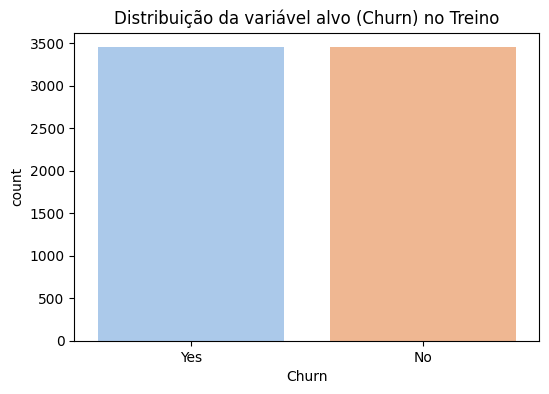

In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(x=train_data["Churn"], palette="pastel")
plt.title("Distribuição da variável alvo (Churn) no Treino")
plt.show()

Como já haviamos feito o oversampling na base de treinamento não vamos precisar nos preocupar com desbalanceamento

## Verificar dados ausentes

In [18]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6898 entries, 0 to 6897
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            6898 non-null   object 
 1   SeniorCitizen     6898 non-null   int64  
 2   Partner           6898 non-null   object 
 3   Dependents        6898 non-null   object 
 4   tenure            6898 non-null   int64  
 5   PhoneService      6898 non-null   object 
 6   MultipleLines     6898 non-null   object 
 7   InternetService   6898 non-null   object 
 8   OnlineSecurity    6898 non-null   object 
 9   OnlineBackup      6898 non-null   object 
 10  DeviceProtection  6898 non-null   object 
 11  TechSupport       6898 non-null   object 
 12  StreamingTV       6898 non-null   object 
 13  StreamingMovies   6898 non-null   object 
 14  Contract          6898 non-null   object 
 15  PaperlessBilling  6898 non-null   object 
 16  PaymentMethod     6898 non-null   object 


In [19]:
train_data.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        6
Churn               0
dtype: int64

Valores ausentes:

* A coluna TotalCharges tem 6 valores ausentes (6892 em 6898 não nulos).

Tipos de dados:

* Variáveis categóricas (object): gender, Partner, Dependents, etc.
* Variáveis numéricas (int64, float64): tenure, MonthlyCharges, TotalCharges e SeniorCitizen.


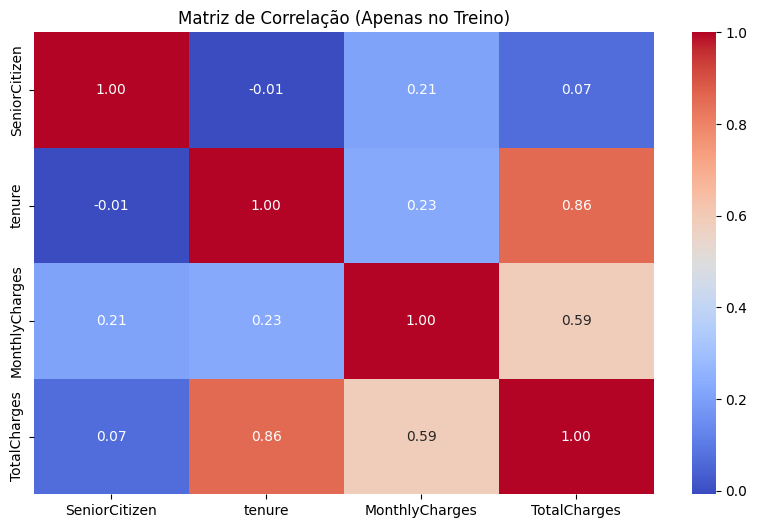

In [20]:
# Correlação entre variáveis numéricas
numeric_cols = train_data.select_dtypes(include=['number']).columns
plt.figure(figsize=(10, 6))
sns.heatmap(train_data[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação (Apenas no Treino)")
plt.show()

A correlação entre TotalCharges e tenure (0.86) e entre TotalCharges e MonthlyCharges (0.59) indica que essa variável tem uma relação forte com outras. Isso sugere que simplesmente removê-la pode levar à perda de uma informação importante.

Vamos analisar as linhas pra entender o que pode tá acontencendo.

In [21]:
train_data[train_data.isnull().any(axis=1)]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
345,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
409,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
3865,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
4344,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
4635,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6373,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No


Todas as linhas que contém NaN é apenas na coluna de TotalCharges e todas essas linhas tem em comum que o Tenure é 0, ou seja, o número de meses que o cliente permaneceu na empresa, como essa váriavel é zero, faz mais sentido deixar as linhas NaN na coluna TotalCharges como 0 também.

In [22]:
train_data['TotalCharges'] = train_data['TotalCharges'].fillna(0)

In [23]:
train_data.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Agora não temos mais dados faltantes

## One-Hot Encoding para variáveis categóricas com múltiplas categorias

In [24]:
def preprocess_one_hot(data):
    """Aplica One-Hot Encoding nas colunas categóricas pré-definidas."""
    categorical_cols = ['InternetService', 'Contract', 'PaymentMethod', 'MultipleLines',
                        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                        'StreamingTV', 'StreamingMovies']
    return pd.get_dummies(data, columns=categorical_cols, drop_first=True)


In [25]:
train_data = preprocess_one_hot(train_data)

## Label Encoding para variáveis binárias

In [26]:
def preprocess_label_encoding(data):
    """Aplica Label Encoding nas colunas binárias pré-definidas."""
    binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]

    # Mapeamento atualizado para evitar NaN
    mapping = {
        "Yes": 1, "No": 0,
        "Male": 1, "Female": 0  # Adicionado para tratar a coluna "gender"
    }

    for col in binary_cols:
        if col in data.columns:  # Verifica se a coluna existe antes de mapear
            data[col] = data[col].map(mapping)

    return data

In [27]:
train_data = preprocess_label_encoding(train_data)

## Verifique se o dataset está pronto (com o mínimo de alteracões possível nesse primeiro caso)

In [28]:
train_data.dtypes

gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
InternetService_Fiber optic                 bool
InternetService_No                          bool
Contract_One year                           bool
Contract_Two year                           bool
PaymentMethod_Credit card (automatic)       bool
PaymentMethod_Electronic check              bool
PaymentMethod_Mailed check                  bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes  

Como não há colunas do tipo object podemos fazer o treinamento

In [29]:
train_data.isnull().sum()

gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
InternetService_Fiber optic              0
InternetService_No                       0
Contract_One year                        0
Contract_Two year                        0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMethod_Mailed check               0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProte

# Treinamento Inicial

Fazer as mesmas transformações no fold de teste também

In [30]:
val_data = folds[0][1]
test_data = folds[0][2]

In [31]:
val_data['TotalCharges'] = val_data['TotalCharges'].fillna(0)
test_data['TotalCharges'] = test_data['TotalCharges'].fillna(0)

In [32]:
val_data = preprocess_one_hot(val_data)
test_data = preprocess_one_hot(test_data)

In [33]:
val_data = preprocess_label_encoding(val_data)
test_data = preprocess_label_encoding(test_data)

In [34]:
# Separando as features (X) e os rótulos (y) para o treino
X_train = train_data.drop(columns=['Churn'])  # Features (dados de entrada) para treino
y_train = train_data['Churn']  # Rótulos (target) para treino

In [35]:
# Separando as features (X) e os rótulos (y) para a validação
X_val = val_data.drop(columns=['Churn'])  # Features (dados de entrada) para validação
y_val = val_data['Churn']  # Rótulos (target) para validação

In [36]:
# Separando as features (X) e os rótulos (y) para o teste
X_test = test_data.drop(columns=['Churn'])  # Features (dados de entrada) para teste
y_test = test_data['Churn']  # Rótulos (target) para teste

## MLP

Com ReLU, Adam, taxa de aprendizado 0.001.

In [37]:
# Treinando MLP básico
mlp = MLPClassifier(hidden_layer_sizes=(100,),  # Número de neurônios nas camadas ocultas
                    activation='relu',          # Função de ativação ReLU
                    solver='adam',              # Otimizador Adam
                    learning_rate_init=0.001,   # Taxa de aprendizado de 0.001
                    max_iter=500,               # Número máximo de iterações
                    random_state=42)            # Fixando a semente para reprodutibilidade

In [38]:
# Treinando o modelo
mlp.fit(X_train, y_train)

MLPClassifier(max_iter=500, random_state=42)

In [39]:
# Validando o modelo com o conjunto de validação
val_predictions = mlp.predict(X_val)

In [40]:
val_accuracy = accuracy_score(y_val, val_predictions)
print(f'Validation Accuracy: {val_accuracy}')

Validation Accuracy: 0.7787234042553192


In [41]:
# Realizando previsões com os dados de teste
y_pred = mlp.predict(X_test)

In [42]:
# Avaliando o modelo nos dados de teste
test_accuracy = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {test_accuracy}')

Test Accuracy: 0.7774936061381074


In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Fazendo previsões no conjunto de teste
y_test_pred = mlp.predict(X_test)

# Calculando métricas
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
conf_matrix = confusion_matrix(y_test, y_test_pred)

# Exibindo os resultados
print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("\nMatriz de Confusão:")
print(conf_matrix)

# Relatório detalhado
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_test_pred))


Acurácia: 0.7775
Precisão: 0.5635
Recall: 0.7138
F1-score: 0.6298

Matriz de Confusão:
[[690 172]
 [ 89 222]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.89      0.80      0.84       862
           1       0.56      0.71      0.63       311

    accuracy                           0.78      1173
   macro avg       0.72      0.76      0.74      1173
weighted avg       0.80      0.78      0.78      1173



## Random Forest

Com hiperparâmetros padrão.

In [44]:
# Treinando Random Forest básico
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [45]:
# Fazendo previsões
y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

In [46]:
# Calculando a acurácia
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

In [47]:
print(f"Acurácia na validação: {val_acc:.4f}")
print(f"Acurácia no teste: {test_acc:.4f}")

Acurácia na validação: 0.7906
Acurácia no teste: 0.7724


In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Fazendo previsões no conjunto de teste
y_test_pred = rf.predict(X_test)

# Calculando métricas
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
conf_matrix = confusion_matrix(y_test, y_test_pred)

# Exibindo os resultados
print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("\nMatriz de Confusão:")
print(conf_matrix)

# Relatório detalhado
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_test_pred))


Acurácia: 0.7724
Precisão: 0.5753
Recall: 0.5402
F1-score: 0.5572

Matriz de Confusão:
[[738 124]
 [143 168]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       862
           1       0.58      0.54      0.56       311

    accuracy                           0.77      1173
   macro avg       0.71      0.70      0.70      1173
weighted avg       0.77      0.77      0.77      1173



# Ajuste iterativo dos dados

## Identificar outliers

<Figure size 1200x600 with 0 Axes>

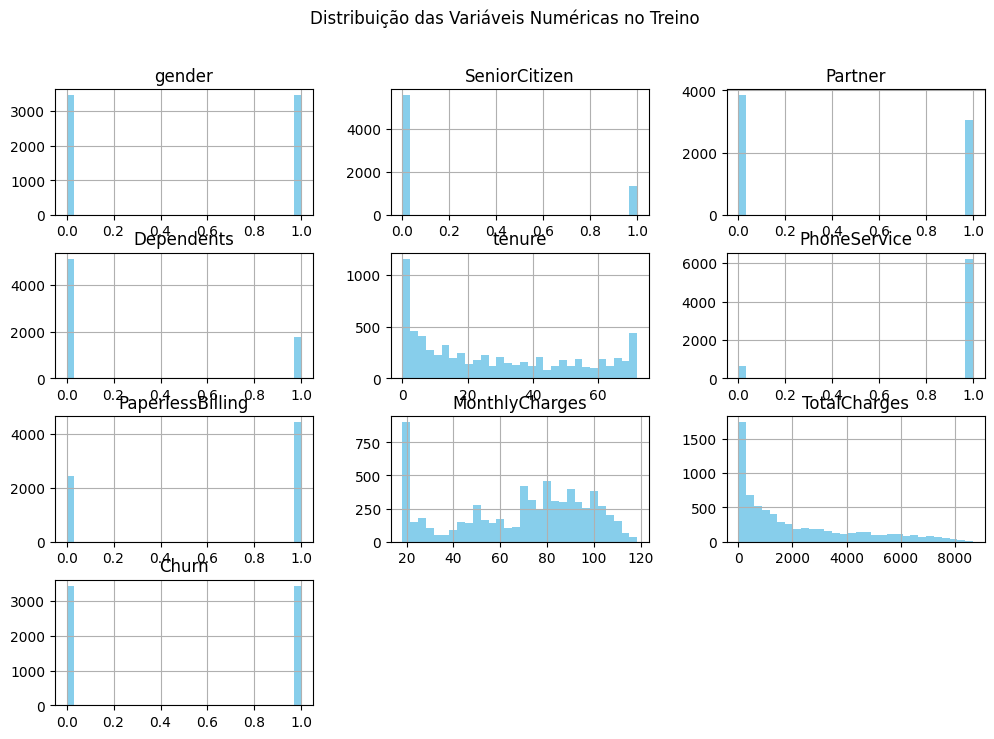

In [49]:
# Distribuição de variáveis numéricas
numeric_cols = train_data.select_dtypes(include=['number']).columns

plt.figure(figsize=(12, 6))
train_data[numeric_cols].hist(bins=30, figsize=(12, 8), color="skyblue")
plt.suptitle("Distribuição das Variáveis Numéricas no Treino")
plt.show()

* SeniorCitizen (Binária)
  
  Só assume os valores 0 e 1, então já está no formato adequado.

* tenure (Tempo de contrato)
  
  Distribuição enviesada à esquerda (muitos valores pequenos).

  Pode ser normalizado (MinMaxScaler).

* MonthlyCharges (Cobrança mensal)
  
  Distribuição aproximadamente normal, mas com um pico inicial.
  
  Pode ser normalizado, dependendo do modelo escolhido.

* TotalCharges

  Tem valores ausentes e está altamente correlacionado com tenure.
  
  Parece seguir um padrão semelhante ao tenure, o que faz sentido (clientes com mais tempo acumulam mais cobranças).

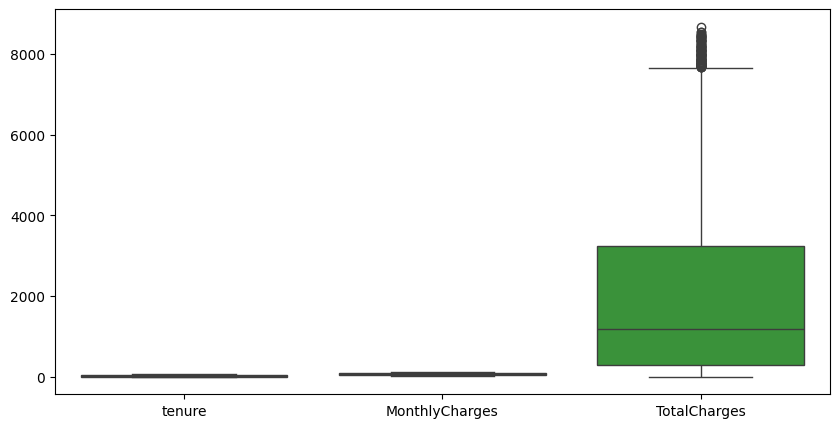

In [50]:
# Identificar outliers
plt.figure(figsize=(10,5))
sns.boxplot(data=train_data[["tenure", "MonthlyCharges", "TotalCharges"]])
plt.show()

Como o objetivo é prever o Churn, os valores muito altos de TotalCharges não necessariamente são "ruídos" nos dados. Na verdade, eles podem conter informações valiosas, já que:

1. Clientes com TotalCharges alto podem ser antigos e, geralmente, têm menos chance de churn (se mantiveram na empresa por muito tempo).
2. Clientes com TotalCharges baixo podem ser novos clientes, que podem estar mais propensos a cancelar (Churn).

**Decisão:**

Em vez de remover os outliers, faz sentido normalizar os valores para que TotalCharges não tenha um impacto desproporcional no modelo.

Além disso, podemos criar bins (faixas) para TotalCharges e ver se existe um padrão entre os grupos e a taxa de churn.

## Transformações de Variáveis

### Tenure

A variável tenure representa o tempo de permanência do cliente.
Os intervalos podem ser definidos com base na distribuição dos dados. Para isso, podemos:

In [51]:
train_data["tenure"].describe()

count    6898.000000
mean       27.897941
std        23.894147
min         0.000000
25%         5.000000
50%        22.000000
75%        49.000000
max        72.000000
Name: tenure, dtype: float64

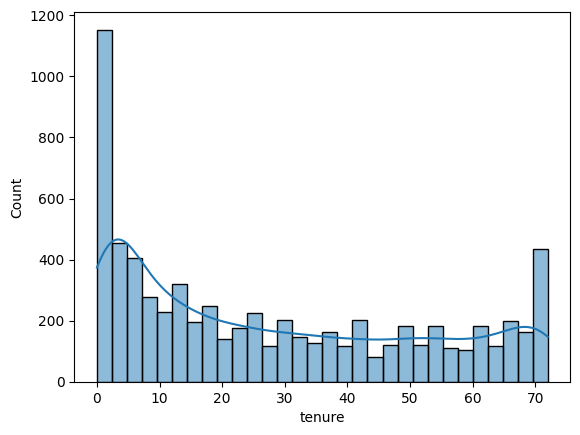

In [52]:
sns.histplot(train_data["tenure"], bins=30, kde=True)
plt.show()

A distribuição de tenure (tempo de permanência do cliente) na imagem mostra que:

1. Há um grande número de clientes com tenure baixo (próximo de 0), o que indica um alto volume de clientes recentes.

2. A distribuição parece bastante dispersa, com valores variando de 0 a 70 meses.

\\
**Ajustando os bins de tenure**


Os bins ([0, 6, 12, 24, 48, 72]) fazem sentido, podemos refiná-los com base na distribuição:

* Clientes Novos (0-6 meses)

* Clientes Iniciais (6-12 meses)

* Clientes Estáveis (1-2 anos)

* Clientes Fiéis (2-4 anos)

* Clientes de Longo Prazo (4-6 anos)

In [53]:
def categorize_tenure(df):
    df["tenure_group"] = pd.cut(df["tenure"],
                                bins=[-1, 6, 12, 24, 48, 72],
                                labels=["0-6m", "6-12m", "1-2y", "2-4y", "4-6y"],
                                right=True)
    return df

In [54]:
train_data = categorize_tenure(train_data)

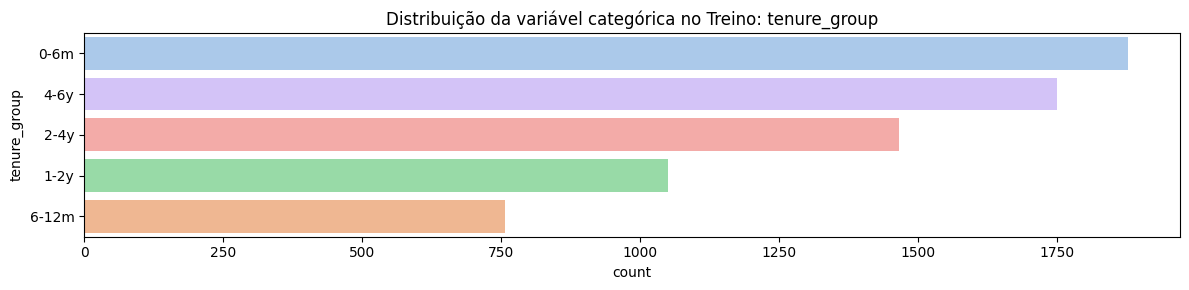

In [55]:
categorical_cols = ['tenure_group']

plt.figure(figsize=(12, len(categorical_cols) * 3))
for i, col in enumerate(categorical_cols):
    plt.subplot(len(categorical_cols), 1, i + 1)
    sns.countplot(y=train_data[col], hue=train_data[col], palette="pastel", order=train_data[col].value_counts().index, legend=False)
    plt.title(f"Distribuição da variável categórica no Treino: {col}")

plt.tight_layout()
plt.show()

### MonthlyCharges

In [56]:
train_data["MonthlyCharges"].describe()

count    6898.000000
mean       68.058169
std        28.916253
min        18.250000
25%        45.300000
50%        74.750000
75%        91.050000
max       118.600000
Name: MonthlyCharges, dtype: float64

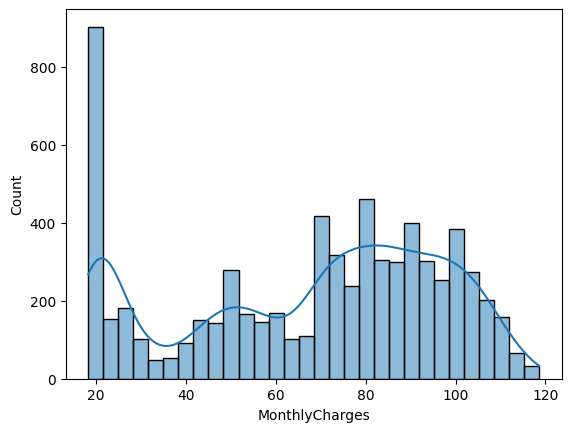

In [57]:
sns.histplot(train_data["MonthlyCharges"], bins=30, kde=True)
plt.show()

**Distribuição Assimétrica:** A maioria dos valores está concentrada na faixa mais baixa (próximo de 20–40), e há uma cauda longa à direita. Isso indica que a maior parte dos clientes paga valores mais baixos, mas há alguns com cobranças bem mais altas.

**Picos e Agrupamentos:** Existem vários picos ao longo do gráfico, sugerindo que certas faixas de preço são mais comuns. Pode ser um reflexo de diferentes planos ou pacotes oferecidos pela empresa.

**Valores Mínimo e Máximo:**

Mínimo: 18,25

Máximo: 118,60

Média: 68,05

* Mediana: 74,75 (isso mostra que a distribuição tem uma leve inclinação para valores menores)

\\
Podemos dividir pelos quartis (25%, 50%, 75%)

In [58]:
def categorize_monthly_charges(df):
    df["monthly_charges_group"] = pd.cut(df["MonthlyCharges"],
                                bins=[-1, 45.30, 74.75, 91.05, 120],
                                labels=["Low", "Medium", "High", "Very High"],
                                right=True)
    return df

In [59]:
train_data = categorize_monthly_charges(train_data)

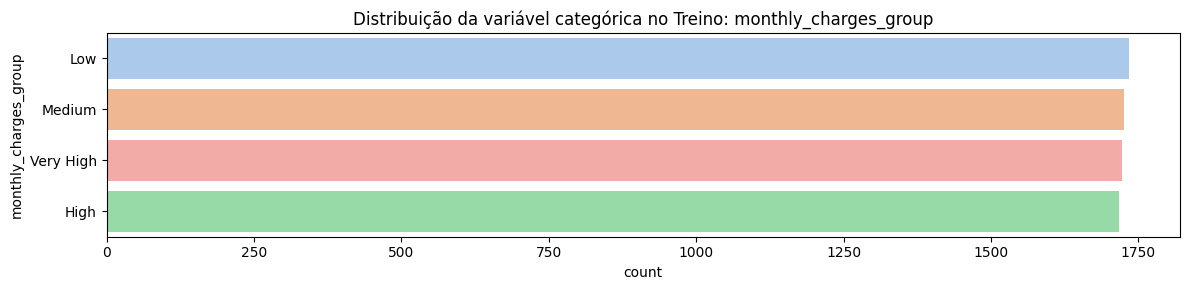

In [60]:
categorical_cols = ['monthly_charges_group']

plt.figure(figsize=(12, len(categorical_cols) * 3))
for i, col in enumerate(categorical_cols):
    plt.subplot(len(categorical_cols), 1, i + 1)
    sns.countplot(y=train_data[col], hue=train_data[col], palette="pastel", order=train_data[col].value_counts().index, legend=False)
    plt.title(f"Distribuição da variável categórica no Treino: {col}")

plt.tight_layout()
plt.show()

### TotalCharges

In [61]:
train_data["TotalCharges"].describe()

count    6898.000000
mean     2053.810322
std      2172.832531
min         0.000000
25%       281.000000
50%      1178.575000
75%      3232.612500
max      8670.100000
Name: TotalCharges, dtype: float64

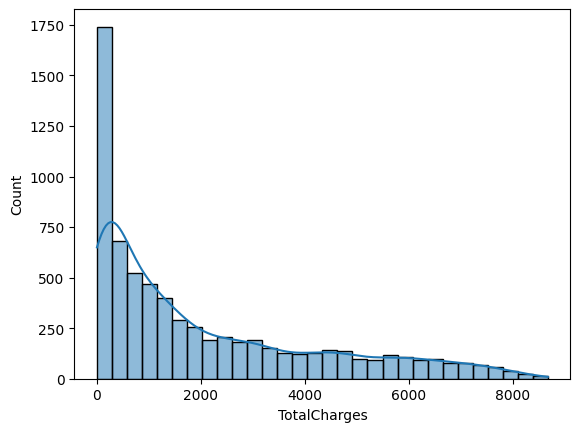

In [62]:
sns.histplot(train_data["TotalCharges"], bins=30, kde=True)
plt.show()

In [63]:
def categorize_total_changes(df):
    df["total_charges_group"] = pd.cut(df["TotalCharges"],
                                bins=[-1, 281, 1178.58, 3232.61, 9980],
                                labels=["Low", "Medium", "High", "Very High"],
                                right=True)
    return df

In [64]:
train_data = categorize_total_changes(train_data)

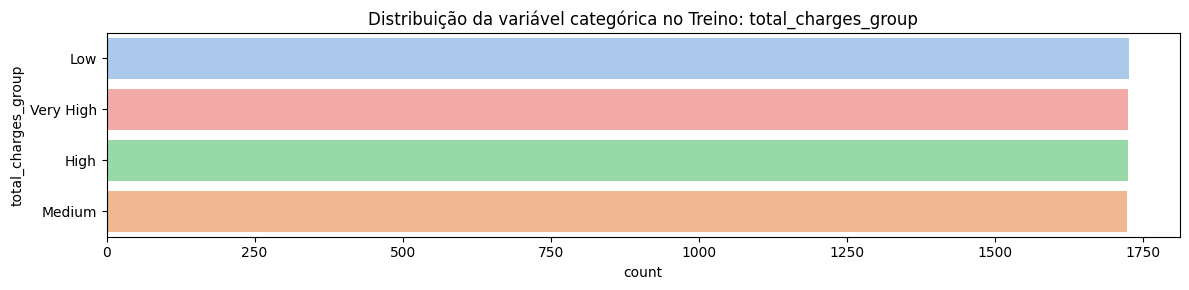

In [65]:
categorical_cols = ['total_charges_group']

plt.figure(figsize=(12, len(categorical_cols) * 3))
for i, col in enumerate(categorical_cols):
    plt.subplot(len(categorical_cols), 1, i + 1)
    sns.countplot(y=train_data[col], hue=train_data[col], palette="pastel", order=train_data[col].value_counts().index, legend=False)
    plt.title(f"Distribuição da variável categórica no Treino: {col}")

plt.tight_layout()
plt.show()

### Normalização


As colunas numéricas que devem ser normalizadas são: "tenure", "MonthlyCharges", "TotalCharges". Usamos a normalização para que os valores fiquem em um intervalo [0, 1].

In [66]:
def normalize(df):
  numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
  scaler = MinMaxScaler()
  df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
  return df

In [67]:
train_data = normalize(train_data)

In [68]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6898 entries, 0 to 6897
Data columns (total 34 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   gender                                 6898 non-null   int64   
 1   SeniorCitizen                          6898 non-null   int64   
 2   Partner                                6898 non-null   int64   
 3   Dependents                             6898 non-null   int64   
 4   tenure                                 6898 non-null   float64 
 5   PhoneService                           6898 non-null   int64   
 6   PaperlessBilling                       6898 non-null   int64   
 7   MonthlyCharges                         6898 non-null   float64 
 8   TotalCharges                           6898 non-null   float64 
 9   Churn                                  6898 non-null   int64   
 10  InternetService_Fiber optic            6898 non-null   bool 

### Explicação

<Figure size 1200x600 with 0 Axes>

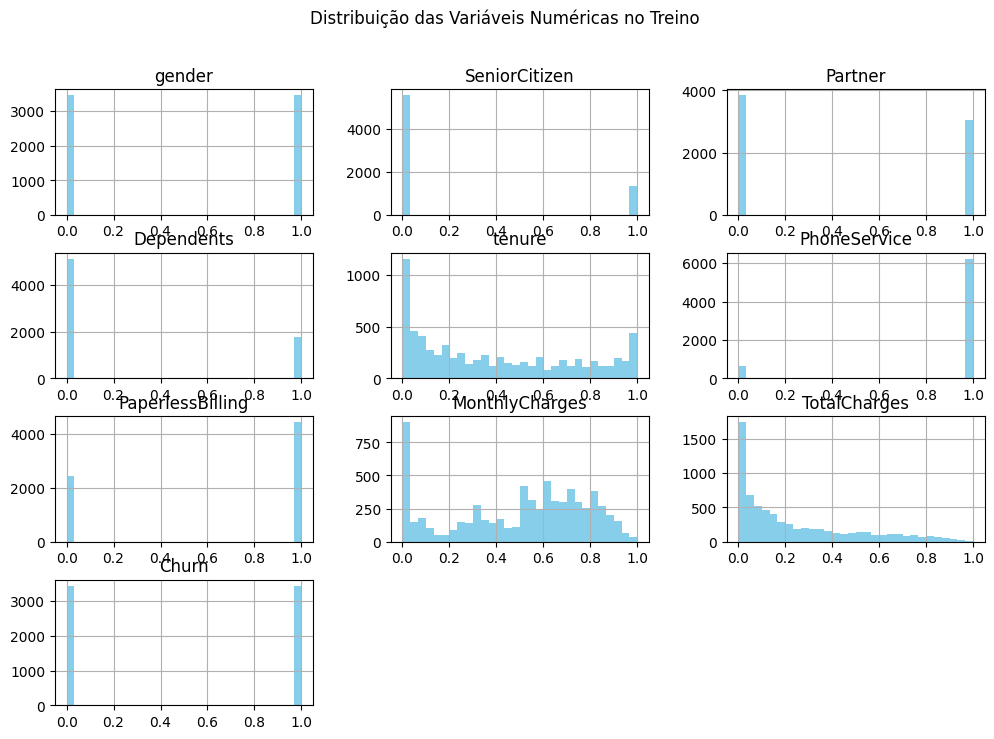

In [69]:
# Distribuição de variáveis numéricas
numeric_cols = train_data.select_dtypes(include=['number']).columns

plt.figure(figsize=(12, 6))
train_data[numeric_cols].hist(bins=30, figsize=(12, 8), color="skyblue")
plt.suptitle("Distribuição das Variáveis Numéricas no Treino")
plt.show()

Percebemos que o tenure, MontlyCharges e TotalCharges estão normaliados, ou seja, seus valores estão entre 0 e 1

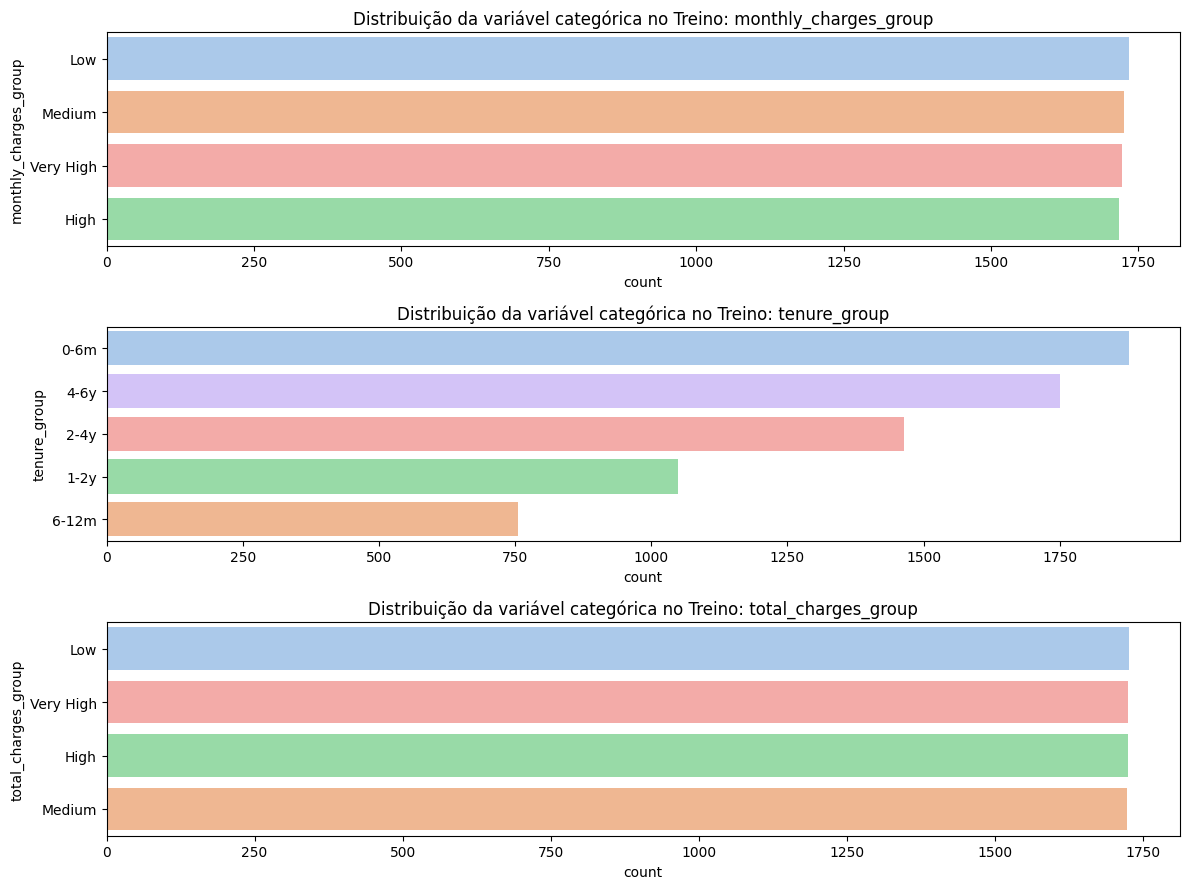

In [70]:
categorical_cols = ['monthly_charges_group', 'tenure_group', 'total_charges_group']

plt.figure(figsize=(12, len(categorical_cols) * 3))
for i, col in enumerate(categorical_cols):
    plt.subplot(len(categorical_cols), 1, i + 1)
    sns.countplot(y=train_data[col], hue=train_data[col], palette="pastel", order=train_data[col].value_counts().index, legend=False)
    plt.title(f"Distribuição da variável categórica no Treino: {col}")

plt.tight_layout()
plt.show()


A categorização das variáveis tenure_group, monthly_charges_group e total_charges_group foi realizada de forma estratégica para garantir um equilíbrio entre representatividade e eficácia no modelo preditivo. A seguir, justificamos por que essa distribuição é a melhor escolha para o problema de previsão de churn.

1. Equilíbrio entre os Grupos
A distribuição das categorias é relativamente uniforme, garantindo que cada grupo tenha uma quantidade significativa de amostras. Isso evita que o modelo tenha viés para uma classe específica e melhora a capacidade de generalização.

Para **monthly_charges_group** e **total_charges_group**, as categorias "Low", "Medium", "High" e "Very High" possuem quantidades semelhantes, o que mantém o aprendizado estável.

No caso do **tenure_group**, os intervalos foram definidos para capturar diferentes fases do cliente na empresa, assegurando que os modelos consigam distinguir padrões de retenção e churn em cada estágio.

2. Captura de Padrões de Churn
Os grupos foram definidos de forma a segmentar os clientes em faixas que fazem sentido do ponto de vista do negócio. Por exemplo:

  * *Clientes com menor tempo de assinatura (0-6 meses) podem ter maior tendência ao churn.*

  * *Clientes com maior tenure (acima de 6 anos) provavelmente já estão mais fidelizados.*

Faixas de cobrança mensais foram estruturadas para refletir diferentes perfis de consumo, permitindo que o modelo identifique padrões específicos relacionados a preços.

Isso garante que a categorização seja relevante para a previsão do churn, evitando cortes arbitrários.

3. Compatibilidade com Diferentes Modelos
Essa abordagem permite a utilização eficiente tanto de modelos baseados em árvores (como Random Forest) quanto de modelos neurais (como MLP):

  * Random Forest lida bem com variáveis categóricas e se beneficia de faixas bem definidas, melhorando a interpretabilidade.

  * MLP pode utilizar essas faixas categóricas em conjunto com variáveis normalizadas para capturar relações não lineares.

Dessa forma, conseguimos o melhor dos dois mundos: boa interpretabilidade e alta capacidade preditiva.

**Conclusão**\
A distribuição das variáveis categorizadas foi definida de maneira otimizada para manter equilíbrio entre os grupos, capturar padrões relevantes de churn e ser compatível com diferentes modelos de machine learning. Essas escolhas maximizam o desempenho da previsão e garantem que o modelo possa fazer inferências mais robustas e generalizáveis.

# Segundo Treinamento

Agora teremos os dados normalizados e com faixas de valores para fazer o treinamento e em seguida veremos se há melhora nos modelos propostos começando com MLP e RF.

In [71]:
val_data = folds[0][1]
test_data = folds[0][2]

In [72]:
train_data['TotalCharges'] = train_data['TotalCharges'].fillna(0)
val_data['TotalCharges'] = val_data['TotalCharges'].fillna(0)
test_data['TotalCharges'] = test_data['TotalCharges'].fillna(0)

In [73]:
val_data.fillna(0, inplace=True)
test_data.fillna(0, inplace=True)

In [74]:
val_data = preprocess_one_hot(val_data)
test_data = preprocess_one_hot(test_data)

In [75]:
val_data = preprocess_label_encoding(val_data)
test_data = preprocess_label_encoding(test_data)

In [76]:
val_data = categorize_monthly_charges(val_data)
test_data = categorize_monthly_charges(test_data)

In [77]:
val_data = categorize_tenure(val_data)
test_data = categorize_tenure(test_data)

In [78]:
val_data = categorize_total_changes(val_data)
test_data = categorize_total_changes(test_data)

In [79]:
val_data = normalize(val_data)
test_data = normalize(test_data)

In [80]:
# Separando as features (X) e os rótulos (y) para o treino
X_train = train_data.drop(columns=['Churn'])  # Features (dados de entrada) para treino
y_train = train_data['Churn']  # Rótulos (target) para treino

In [81]:
# Separando as features (X) e os rótulos (y) para a validação
X_val = val_data.drop(columns=['Churn'])  # Features (dados de entrada) para validação
y_val = val_data['Churn']  # Rótulos (target) para validação

In [82]:
# Separando as features (X) e os rótulos (y) para o teste
X_test = test_data.drop(columns=['Churn'])  # Features (dados de entrada) para teste
y_test = test_data['Churn']  # Rótulos (target) para teste

In [83]:
X_train_mlp = X_train.drop(columns=['monthly_charges_group', 'tenure_group', 'total_charges_group'])  # Removendo groups para MLP
X_val_mlp = X_val.drop(columns=['monthly_charges_group', 'tenure_group', 'total_charges_group'])
X_test_mlp = X_test.drop(columns=['monthly_charges_group', 'tenure_group', 'total_charges_group'])

In [84]:
X_train_rf = X_train.drop(columns=['MonthlyCharges', 'tenure', 'TotalCharges'])  # Removendo normalizadas para RF
X_val_rf = X_val.drop(columns=['MonthlyCharges', 'tenure', 'TotalCharges'])
X_test_rf = X_test.drop(columns=['MonthlyCharges', 'tenure', 'TotalCharges'])

categorical_cols_rf = X_train_rf.select_dtypes(include=['category']).columns
print("Colunas categóricas no RF:", categorical_cols_rf)

label_encoder = LabelEncoder()

for col in categorical_cols:
    X_train_rf[col] = label_encoder.fit_transform(X_train_rf[col])
    X_val_rf[col] = label_encoder.transform(X_val_rf[col])
    X_test_rf[col] = label_encoder.transform(X_test_rf[col])


Colunas categóricas no RF: Index(['tenure_group', 'monthly_charges_group', 'total_charges_group'], dtype='object')


In [85]:
X_train_rf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6898 entries, 0 to 6897
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   gender                                 6898 non-null   int64
 1   SeniorCitizen                          6898 non-null   int64
 2   Partner                                6898 non-null   int64
 3   Dependents                             6898 non-null   int64
 4   PhoneService                           6898 non-null   int64
 5   PaperlessBilling                       6898 non-null   int64
 6   InternetService_Fiber optic            6898 non-null   bool 
 7   InternetService_No                     6898 non-null   bool 
 8   Contract_One year                      6898 non-null   bool 
 9   Contract_Two year                      6898 non-null   bool 
 10  PaymentMethod_Credit card (automatic)  6898 non-null   bool 
 11  PaymentMethod_Electronic check

Quando as categorias seguem uma progressão lógica como "Baixo" → "Médio" → "Alto" → "Muito Alto", elas possuem uma ordem natural.

Logo, Label Enconding se torna a melhor opção.

## MLP

Com ReLU, Adam, taca de aprendizado 0.0001

In [86]:
# Treinando MLP básico
mlp = MLPClassifier(hidden_layer_sizes=(100,),  # Número de neurônios nas camadas ocultas
                    activation='relu',          # Função de ativação ReLU
                    solver='adam',              # Otimizador Adam
                    learning_rate_init=0.001,   # Taxa de aprendizado de 0.001
                    max_iter=500,               # Número máximo de iterações
                    random_state=42)            # Fixando a semente para reprodutibilidade

In [87]:
# Treinando o modelo
mlp.fit(X_train_mlp, y_train)

MLPClassifier(max_iter=500, random_state=42)

In [88]:
# Validando o modelo com o conjunto de validação
val_predictions = mlp.predict(X_val_mlp)

In [89]:
val_accuracy = accuracy_score(y_val, val_predictions)
print(f'Validation Accuracy: {val_accuracy}')

Validation Accuracy: 0.7668085106382979


In [90]:
# Realizando previsões com os dados de teste
y_pred = mlp.predict(X_test_mlp)

In [91]:
# Avaliando o modelo nos dados de teste
test_accuracy = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {test_accuracy}')

Test Accuracy: 0.7510656436487638


In [92]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Fazendo previsões no conjunto de teste
y_test_pred = mlp.predict(X_test_mlp)

# Calculando métricas
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
conf_matrix = confusion_matrix(y_test, y_test_pred)

# Exibindo os resultados
print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("\nMatriz de Confusão:")
print(conf_matrix)

# Relatório detalhado
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_test_pred))


Acurácia: 0.7511
Precisão: 0.5242
Recall: 0.6624
F1-score: 0.5852

Matriz de Confusão:
[[675 187]
 [105 206]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.87      0.78      0.82       862
           1       0.52      0.66      0.59       311

    accuracy                           0.75      1173
   macro avg       0.69      0.72      0.70      1173
weighted avg       0.77      0.75      0.76      1173



## Random Forest

Com hiperparâmetros padrão.

In [93]:
# Treinando Random Forest básico
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_rf, y_train)

RandomForestClassifier(random_state=42)

In [94]:
# Garantir que as colunas de X_val_rf e X_test_rf estejam na mesma ordem que X_train_rf
X_val_rf = X_val_rf[X_train_rf.columns]
X_test_rf = X_test_rf[X_train_rf.columns]

# Agora, faça as previsões
y_val_pred = rf.predict(X_val_rf)
y_test_pred = rf.predict(X_test_rf)

In [95]:
# Calculando a acurácia
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

In [96]:
print(f"Acurácia na validação: {val_acc:.4f}")
print(f"Acurácia no teste: {test_acc:.4f}")

Acurácia na validação: 0.7677
Acurácia no teste: 0.7587


In [97]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Fazendo previsões no conjunto de teste
y_test_pred = rf.predict(X_test_rf)

# Calculando métricas
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
conf_matrix = confusion_matrix(y_test, y_test_pred)

# Exibindo os resultados
print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("\nMatriz de Confusão:")
print(conf_matrix)

# Relatório detalhado
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_test_pred))


Acurácia: 0.7587
Precisão: 0.5419
Recall: 0.5820
F1-score: 0.5612

Matriz de Confusão:
[[709 153]
 [130 181]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.85      0.82      0.83       862
           1       0.54      0.58      0.56       311

    accuracy                           0.76      1173
   macro avg       0.69      0.70      0.70      1173
weighted avg       0.76      0.76      0.76      1173



## Analise Comparativa

O desempenho da nossa **MLP** piorou no segundo treinamento, com uma queda na acurácia, precisão, recall e F1-score, especialmente para a classe 1 (churn). A principal razão para isso parece ser o aumento no número de falsos negativos (não identificar churns reais) e a diminuição da precisão ao prever a classe 1, indicando que o modelo não está conseguindo identificar churns de forma tão eficaz quanto no primeiro treinamento.

**Próximos Passos:**
* Ajustar o modelo: Pode ser necessário ajustar os hiperparâmetros, como o número de camadas e neurônios do MLP, a taxa de aprendizado ou o algoritmo de otimização.

* Explorar mais as características dos dados: A inclusão de novas features ou transformação diferente das variáveis pode melhorar a previsão.

* Ajustar o threshold de decisão: Modificar o limiar para classificar um exemplo como churn ou não pode melhorar o desempenho, especialmente no recall e precisão para a classe 1.

Esses ajustes podem ajudar a melhorar a capacidade do modelo em identificar corretamente os churns.

Já o primeiro modelo da **RF** tem uma acurácia melhor e é um pouco melhor em termos de precisão para a classe 1 (churn), mas tem um recall menor para essa classe.

O segundo modelo apresenta um recall superior, indicando que ele está conseguindo identificar mais churns reais, mas sacrifica um pouco a precisão. Ele parece ter um pequeno equilíbrio mais favorável entre precisão e recall, embora a diferença seja pequena.

Em resumo, ambos os modelos têm seus pontos fortes e fracos, com o primeiro modelo sendo um pouco melhor para identificar corretamente a classe majoritária (não churn), enquanto o segundo modelo apresenta um desempenho ligeiramente melhor para identificar churns reais (classe 1), embora com um custo em precisão.

**Com isso vamos retornar ao modelo anterior sem categorização e apenas com normalização**

# Otimização dos hiperparâmetros

## Otimização de Hiperparâmetros para Random Forest e Gradient Boosting usando Optuna

## Pré-processamento

### Geral

In [98]:
def preprocess_general(data):

    data['TotalCharges'] = data['TotalCharges'].fillna(0)
    data.fillna(0, inplace=True)

    data = preprocess_one_hot(data)
    data = preprocess_label_encoding(data)

    # data = categorize_monthly_charges(data)
    # data = categorize_tenure(data)
    # data = categorize_total_changes(data)

    return data

In [99]:
def preprocess_rf(data):
    data = data.drop(columns=['MonthlyCharges', 'tenure', 'TotalCharges'])

    categorical_cols_rf = X_train_rf.select_dtypes(include=['category']).columns
    label_encoder = LabelEncoder()

    for col in categorical_cols_rf:
        data[col] = label_encoder.fit_transform(data[col])

    return data

In [100]:
def preprocess_mlp(data):
    data = normalize(data)
    # data = data.drop(columns=['monthly_charges_group', 'tenure_group', 'total_charges_group'])
    return data

In [101]:
def plot_ks_curve(y_true, y_pred_proba, fold_idx):
    """ Plota a curva KS e retorna o KS Score """
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    ks_values = tpr - fpr
    ks_score = np.max(ks_values)
    ks_threshold = thresholds[np.argmax(ks_values)]

    plt.figure(figsize=(6, 5))
    plt.plot(thresholds, tpr, label='TPR (Taxa de Verdadeiros Positivos)', color='blue')
    plt.plot(thresholds, fpr, label='FPR (Taxa de Falsos Positivos)', color='red')
    plt.axvline(ks_threshold, color='black', linestyle='--', label=f'KS = {ks_score:.4f}')

    plt.xlabel('Threshold')
    plt.ylabel('Taxa Acumulada')
    plt.title(f'Curva KS - Fold {fold_idx}')
    plt.legend()
    plt.grid()
    plt.xlim([0, 1])
    plt.show()

    return ks_score

### Random Forest

In [102]:
def objective_rf(trial):
    # Sugerir hiperparâmetros
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

    # Corrigido para valores válidos de max_features
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    accuracy_list = []

    # K-Fold Cross Validation (usando seus folds)
    for fold in folds:
        train_data, val_data, test_data = fold
        train_data = preprocess_general(train_data)
        val_data = preprocess_general(val_data)
        test_data = preprocess_general(test_data)

        X_train, y_train = train_data.drop(columns=['Churn']), train_data['Churn']
        X_val, y_val = val_data.drop(columns=['Churn']), val_data['Churn']

        # Criação do modelo RandomForest
        rf = RandomForestClassifier(n_estimators=n_estimators,
                                    max_depth=max_depth,
                                    min_samples_leaf=min_samples_leaf,
                                    max_features=max_features,
                                    random_state=42)

        # Treinamento do modelo
        rf.fit(X_train, y_train)

        # Previsões e avaliação
        y_pred = mlp.predict(X_val)
        accuracy = accuracy_score(y_val, y_pred)
        accuracy_list.append(accuracy)

    return np.mean(accuracy_list)

In [103]:
# Criar o estudo para Random Forest
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=50)  # Tente 50 diferentes combinações de parâmetros
print("Melhores Hiperparâmetros para Random Forest:", study_rf.best_params)

[I 2025-04-09 11:50:56,239] A new study created in memory with name: no-name-60198e78-b7aa-4402-91ae-d79a7cb70ff4
[I 2025-04-09 11:50:57,178] Trial 0 finished with value: 0.7343926927398602 and parameters: {'n_estimators': 50, 'max_depth': 16, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 0.7343926927398602.
[I 2025-04-09 11:51:03,370] Trial 1 finished with value: 0.7343926927398602 and parameters: {'n_estimators': 139, 'max_depth': 8, 'min_samples_leaf': 5, 'max_features': None}. Best is trial 0 with value: 0.7343926927398602.
[I 2025-04-09 11:51:12,338] Trial 2 finished with value: 0.7343926927398602 and parameters: {'n_estimators': 161, 'max_depth': 19, 'min_samples_leaf': 9, 'max_features': None}. Best is trial 0 with value: 0.7343926927398602.
[I 2025-04-09 11:51:13,491] Trial 3 finished with value: 0.7343926927398602 and parameters: {'n_estimators': 65, 'max_depth': 8, 'min_samples_leaf': 10, 'max_features': 'log2'}. Best is trial 0 with value: 0.734

Melhores Hiperparâmetros para Random Forest: {'n_estimators': 50, 'max_depth': 16, 'min_samples_leaf': 6, 'max_features': 'log2'}


In [104]:
def train_model_rf(model, folds, model_name):
    accuracy_list = []
    mse_list = []
    roc_auc_list = []
    precision_list = []
    recall_list = []
    f1_list = []
    log_loss_list = []
    ks_list = []  # <-- NOVO: Lista para armazenar KS

    for fold_idx, (train_data, val_data, test_data) in enumerate(folds):
        print(f"Treinando {model_name} - Fold {fold_idx + 1}")

        # Pré-processamento
        train_data = preprocess_general(train_data)
        val_data = preprocess_general(val_data)
        test_data = preprocess_general(test_data)

        train_data = preprocess_mlp(train_data)
        val_data = preprocess_mlp(val_data)
        test_data = preprocess_mlp(test_data)

        # Separação de features e labels
        X_train, y_train = train_data.drop(columns=['Churn']), train_data['Churn']
        X_val, y_val = val_data.drop(columns=['Churn']), val_data['Churn']
        X_test, y_test = test_data.drop(columns=['Churn']), test_data['Churn']

        # Treinamento
        model.fit(X_train, y_train)

        # Predições
        y_test_pred = model.predict(X_test)
        y_test_proba = model.predict_proba(X_test)[:, 1]  # Necessário para KS, ROC, LogLoss

        # Métricas
        test_accuracy = accuracy_score(y_test, y_test_pred)
        mse = mean_squared_error(y_test, y_test_pred)
        roc_auc = roc_auc_score(y_test, y_test_proba)
        precision = precision_score(y_test, y_test_pred)
        recall = recall_score(y_test, y_test_pred)
        f1 = f1_score(y_test, y_test_pred)
        log_loss_value = log_loss(y_test, y_test_proba)

        # Armazenar métricas
        accuracy_list.append(test_accuracy)
        mse_list.append(mse)
        roc_auc_list.append(roc_auc)
        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)
        log_loss_list.append(log_loss_value)

        # Matriz de Confusão
        cm = confusion_matrix(y_test, y_test_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'])
        plt.title(f'Matriz de Confusão - Fold {fold_idx + 1}')
        plt.xlabel('Predição')
        plt.ylabel('Real')
        plt.show()

        # Curva ROC
        fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('Taxa de Falsos Positivos')
        plt.ylabel('Taxa de Verdadeiros Positivos')
        plt.title(f'Curva ROC - Fold {fold_idx + 1}')
        plt.legend(loc='lower right')
        plt.show()

        # KS Score e Gráfico
        ks_score = plot_ks_curve(y_test, y_test_proba, fold_idx + 1)
        ks_list.append(ks_score)

        # Prints
        print(f"Fold {fold_idx + 1} | Accuracy: {test_accuracy:.4f} | MSE: {mse:.4f} | ROC AUC: {roc_auc:.4f}")
        print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | LogLoss: {log_loss_value:.4f}")
        print(f"KS Score: {ks_score:.4f}")

    return (np.mean(accuracy_list), np.mean(mse_list), np.mean(roc_auc_list),
            np.mean(precision_list), np.mean(recall_list), np.mean(f1_list),
            np.mean(log_loss_list), np.mean(ks_list),  np.std(ks_list)) 


Treinando rf - Fold 1


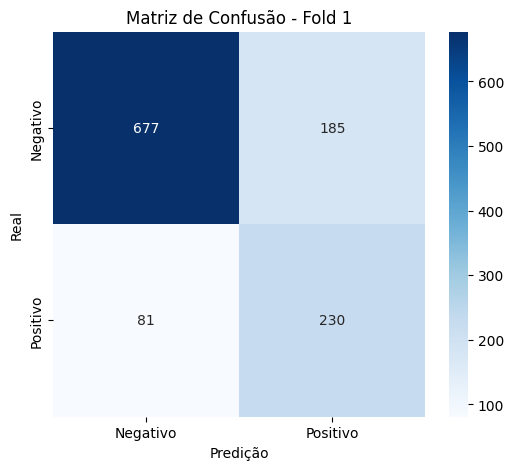

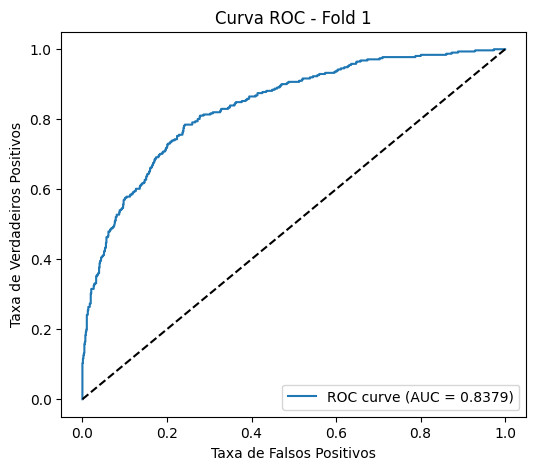

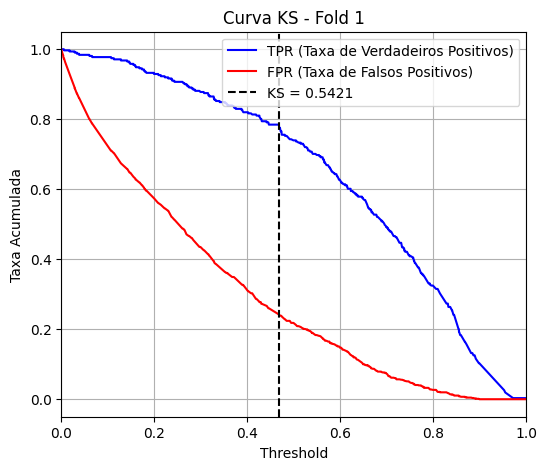

Fold 1 | Accuracy: 0.7732 | MSE: 0.2268 | ROC AUC: 0.8379
Precision: 0.5542 | Recall: 0.7395 | F1: 0.6336 | LogLoss: 0.4701
KS Score: 0.5421
Treinando rf - Fold 2


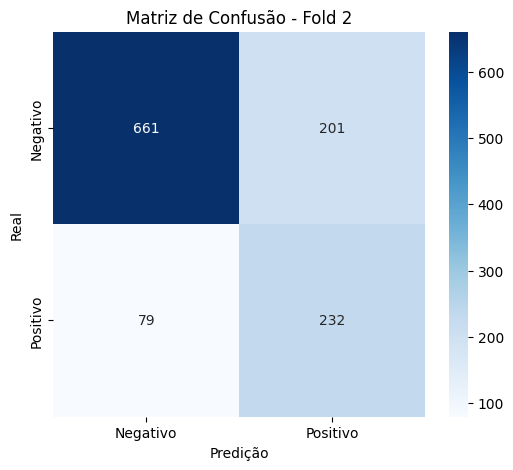

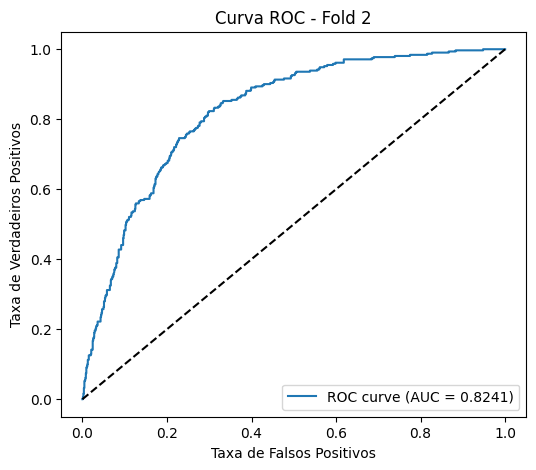

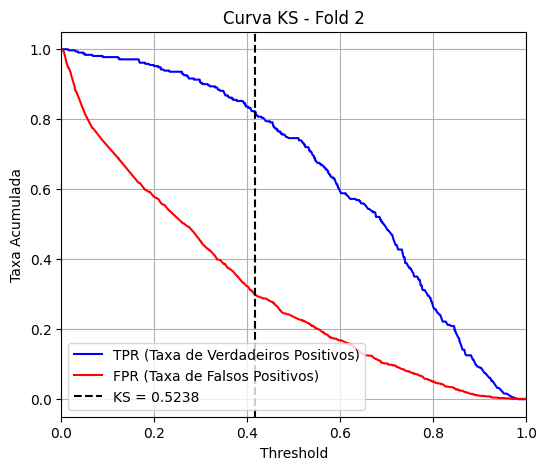

Fold 2 | Accuracy: 0.7613 | MSE: 0.2387 | ROC AUC: 0.8241
Precision: 0.5358 | Recall: 0.7460 | F1: 0.6237 | LogLoss: 0.5004
KS Score: 0.5238
Treinando rf - Fold 3


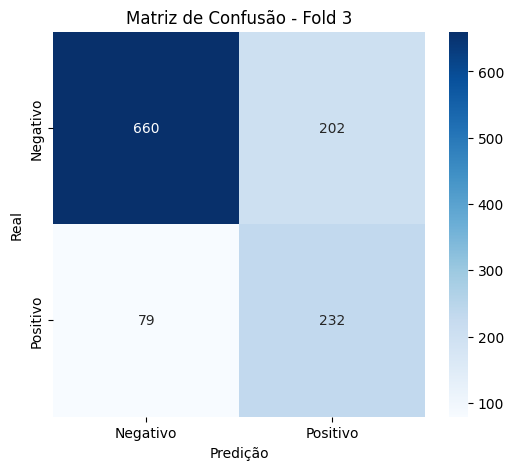

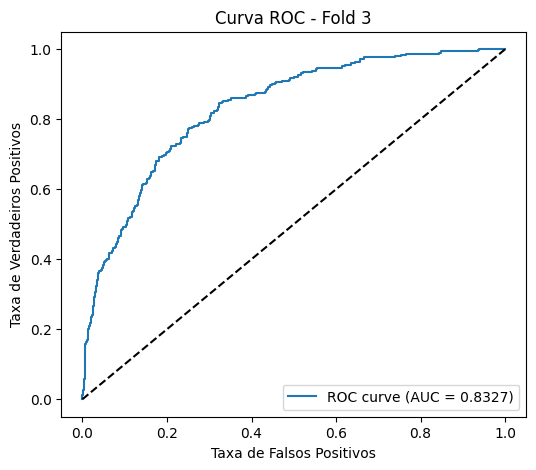

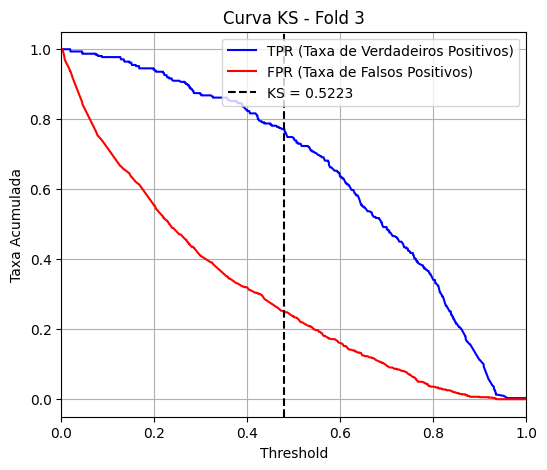

Fold 3 | Accuracy: 0.7604 | MSE: 0.2396 | ROC AUC: 0.8327
Precision: 0.5346 | Recall: 0.7460 | F1: 0.6228 | LogLoss: 0.4812
KS Score: 0.5223
Random Forest - Acurácia Média: 0.7650
Random Forest - MSE Médio: 0.2350
Random Forest - ROC AUC Médio: 0.8316
Random Forest - Precision Médio: 0.5415
Random Forest - Recall Médio: 0.7438
Random Forest - F1-Score Médio: 0.6267
Random Forest - Cross-Entropy (Log Loss) Médio: 0.4839
Random Forest - Kolmogorov-Smirnov (KS) Médio: 0.5294
Random Forest - Kolmogorov-Smirnov (KS) Desvio Padrão: 0.0090


In [105]:
rf_best_params = study_rf.best_params
rf_model = RandomForestClassifier(
    n_estimators=rf_best_params['n_estimators'], 
    max_depth=rf_best_params['max_depth'], 
    min_samples_leaf=rf_best_params['min_samples_leaf'], 
    max_features=rf_best_params['max_features'], 
    random_state=42
)

avg_accuracy, avg_mse, avg_roc_auc, avg_precision, avg_recall, avg_f1, avg_log_loss, avg_ks, std_ks = train_model_rf(rf_model, folds, 'rf')
print(f"Random Forest - Acurácia Média: {avg_accuracy:.4f}")
print(f"Random Forest - MSE Médio: {avg_mse:.4f}")
print(f"Random Forest - ROC AUC Médio: {avg_roc_auc:.4f}")
print(f"Random Forest - Precision Médio: {avg_precision:.4f}")
print(f"Random Forest - Recall Médio: {avg_recall:.4f}")
print(f"Random Forest - F1-Score Médio: {avg_f1:.4f}")
print(f"Random Forest - Cross-Entropy (Log Loss) Médio: {avg_log_loss:.4f}")
print(f"Random Forest - Kolmogorov-Smirnov (KS) Médio: {avg_ks:.4f}")
print(f"Random Forest - Kolmogorov-Smirnov (KS) Desvio Padrão: {std_ks:.4f}")


Esses resultados fornecem uma visão abrangente sobre o desempenho do modelo Random Forest após a validação cruzada. A partir desses valores, podemos tirar algumas conclusões sobre o comportamento do modelo:

1. **Kolmogorov-Smirnov (KS) Score – 0.5294**

O KS Score mede a máxima diferença entre as taxas acumuladas de verdadeiros positivos (TPR) e falsos positivos (FPR), sendo uma métrica particularmente útil para problemas de classificação binária com foco em discriminação de risco ou separação de classes.

Esse indica que o modelo atinge uma boa separação entre as classes positivas e negativas. De modo geral:

* KS > 0.2 → desempenho razoável

* KS > 0.4 → desempenho bom

* KS > 0.6 → excelente

Portanto, esse KS representa um modelo bem eficaz na discriminação entre as classes, especialmente relevante em aplicações como modelo de churn.

**Desvio Padrão do KS: 0.0090**
Esse valor mostra o quanto o KS variou entre os folds da cross-validation.

Esse é um desvio padrão muito pequeno.

Isso significa que o desempenho do modelo foi consistente entre os diferentes conjuntos de treino/teste.

Em outras palavras, o modelo não é sensível à variação dos dados — um sinal de estabilidade e robustez.

2. Acurácia (0.7650)
O modelo tem uma acurácia de 76.50%, o que significa que ele acertou aproximadamente 77% das previsões no conjunto de teste. Isso é um bom valor, mas é importante considerar o contexto do problema. Em problemas de classificação com classes desbalanceadas, a acurácia por si só pode não ser a melhor métrica.

3. ROC AUC (0.8316)
A AUC-ROC é bastante boa. Uma AUC acima de 0.8 geralmente indica que o modelo está bem calibrado para distinguir entre as classes positivas e negativas. Isso significa que o modelo é eficiente em distinguir entre as classes, mesmo que não tenha uma acurácia perfeita.

**Conclusões principais:**

* KS Score como métrica principal mostra que o modelo possui boa capacidade de separação entre as classes, com valor acima de 0.53, o que o torna confiável em contextos como scoring, churn ou risco.

* A combinação de ROC AUC e KS Score reforça que o modelo está bem calibrado para classificação binária, mesmo sem precisão extrema.

* O modelo tem bom recall, o que significa que ele tende a identificar corretamente os positivos, mesmo que à custa de algumas falsas positivas.

### MLP

In [106]:
def objective_mlp(trial):
    hidden_layer_sizes = trial.suggest_int('hidden_layer_sizes', 50, 150)
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])

    learning_rate_init = trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    solver = trial.suggest_categorical('solver', ['adam', 'sgd'])

    accuracy_list = []

    # K-Fold Cross Validation (usando seus folds)
    for fold in folds:
        train_data, val_data, test_data = fold

        train_data = preprocess_general(train_data)
        val_data = preprocess_general(val_data)
        test_data = preprocess_general(test_data)
        
        train_data = preprocess_mlp(train_data)
        val_data = preprocess_mlp(val_data)
        test_data = preprocess_mlp(test_data)

        X_train, y_train = train_data.drop(columns=['Churn']), train_data['Churn']
        X_val, y_val = val_data.drop(columns=['Churn']), val_data['Churn']

        # Criação do modelo MLP
        mlp = MLPClassifier(hidden_layer_sizes=(hidden_layer_sizes,),
                            activation=activation,
                            learning_rate_init=learning_rate_init,
                            batch_size=batch_size,
                            solver=solver,
                            max_iter=5000,
                            random_state=42)
        mlp.fit(X_train, y_train)

        # Previsões e avaliação
        y_pred = mlp.predict(X_val)
        accuracy = accuracy_score(y_val, y_pred)
        accuracy_list.append(accuracy)

    # Retorna a média da acurácia nos folds
    return np.mean(accuracy_list)

In [107]:
# Criar o estudo para MLP
study_mlp = optuna.create_study(direction='maximize')
study_mlp.optimize(objective_mlp, n_trials=50)
print("Melhores Hiperparâmetros para MLP:", study_mlp.best_params)

[I 2025-04-09 11:53:39,913] A new study created in memory with name: no-name-7d701972-35b1-4ea3-a896-9c1bef9d5bad
[I 2025-04-09 11:54:44,460] Trial 0 finished with value: 0.7451757342902364 and parameters: {'hidden_layer_sizes': 146, 'activation': 'relu', 'learning_rate_init': 0.0008074319594355801, 'batch_size': 128, 'solver': 'adam'}. Best is trial 0 with value: 0.7451757342902364.
[I 2025-04-09 11:55:35,345] Trial 1 finished with value: 0.738933149685261 and parameters: {'hidden_layer_sizes': 65, 'activation': 'relu', 'learning_rate_init': 0.0011023770115929483, 'batch_size': 64, 'solver': 'sgd'}. Best is trial 0 with value: 0.7451757342902364.
[I 2025-04-09 11:58:03,826] Trial 2 finished with value: 0.751703698333877 and parameters: {'hidden_layer_sizes': 96, 'activation': 'relu', 'learning_rate_init': 0.00016239696935049994, 'batch_size': 128, 'solver': 'adam'}. Best is trial 2 with value: 0.751703698333877.
[I 2025-04-09 11:58:21,702] Trial 3 finished with value: 0.73354211219447

Melhores Hiperparâmetros para MLP: {'hidden_layer_sizes': 124, 'activation': 'tanh', 'learning_rate_init': 0.0005888606538992622, 'batch_size': 32, 'solver': 'sgd'}


In [112]:
def train_model_mlp(model, folds, model_name, patience=20):
    accuracy_list = []
    mse_list = []
    roc_auc_list = []
    precision_list = []
    recall_list = []
    f1_list = []
    log_loss_list = []
    ks_list = [] 

    for fold_idx, (train_data, val_data, test_data) in enumerate(folds):
        print(f"Treinando {model_name} - Fold {fold_idx + 1}")

        train_data = preprocess_general(train_data)
        val_data = preprocess_general(val_data)
        test_data = preprocess_general(test_data)

        train_data = preprocess_mlp(train_data)
        val_data = preprocess_mlp(val_data)
        test_data = preprocess_mlp(test_data)

        X_train, y_train = train_data.drop(columns=['Churn']), train_data['Churn']
        X_val, y_val = val_data.drop(columns=['Churn']), val_data['Churn']
        X_test, y_test = test_data.drop(columns=['Churn']), test_data['Churn']

        best_accuracy = 0
        patience_counter = 0

        for epoch in range(10000):
            model.partial_fit(X_train, y_train, classes=np.unique(y_train))

            y_val_pred = model.predict(X_val)
            val_accuracy = accuracy_score(y_val, y_val_pred)

            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping no fold {fold_idx + 1} após {epoch + 1} épocas.")
                break

        y_test_pred = model.predict(X_test)
        y_test_proba = model.predict_proba(X_test)[:, 1]

        test_accuracy = accuracy_score(y_test, y_test_pred)
        accuracy_list.append(test_accuracy)

        mse = mean_squared_error(y_test, y_test_pred)
        mse_list.append(mse)

        try:
            roc_auc = roc_auc_score(y_test, y_test_proba)
            roc_auc_list.append(roc_auc)
        except:
            roc_auc = np.nan
            roc_auc_list.append(roc_auc)

        precision = precision_score(y_test, y_test_pred)
        recall = recall_score(y_test, y_test_pred)
        f1 = f1_score(y_test, y_test_pred)

        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)

        log_loss_value = log_loss(y_test, y_test_proba)
        log_loss_list.append(log_loss_value)

        # KS Score e gráfico
        ks_score = plot_ks_curve(y_test, y_test_proba, fold_idx + 1)
        ks_list.append(ks_score)

        cm = confusion_matrix(y_test, y_test_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'])
        plt.title(f'Matriz de Confusão - Fold {fold_idx + 1}')
        plt.xlabel('Predição')
        plt.ylabel('Real')
        plt.show()

        fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('Taxa de Falsos Positivos')
        plt.ylabel('Taxa de Verdadeiros Positivos')
        plt.title(f'Curva ROC - Fold {fold_idx + 1}')
        plt.legend(loc='lower right')
        plt.show()

        print(f"Accuracy no Fold {fold_idx + 1}: Validação: {val_accuracy:.4f}, Teste: {test_accuracy:.4f}")
        print(f"MSE: {mse:.4f} | ROC AUC: {roc_auc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
        print(f"LogLoss: {log_loss_value:.4f} | KS Score: {ks_score:.4f}")

    # Médias
    avg_accuracy = np.mean(accuracy_list)
    avg_mse = np.mean(mse_list)
    avg_roc_auc = np.mean(roc_auc_list)
    avg_precision = np.mean(precision_list)
    avg_recall = np.mean(recall_list)
    avg_f1 = np.mean(f1_list)
    avg_log_loss = np.mean(log_loss_list)
    avg_ks = np.mean(ks_list)

    return (avg_accuracy, avg_mse, avg_roc_auc,
            avg_precision, avg_recall, avg_f1,
            avg_log_loss, avg_ks, np.std(ks_list))


Treinando mlp - Fold 1
Early stopping no fold 1 após 26 épocas.


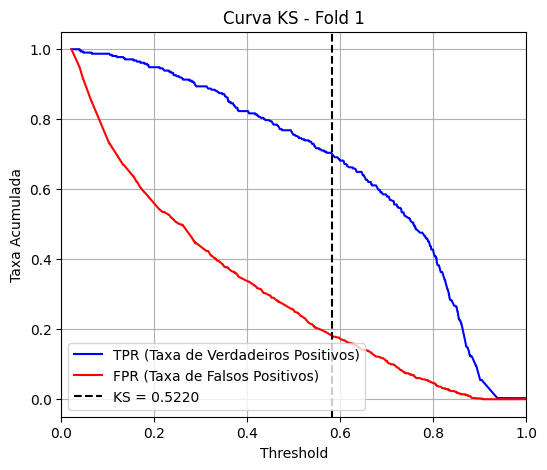

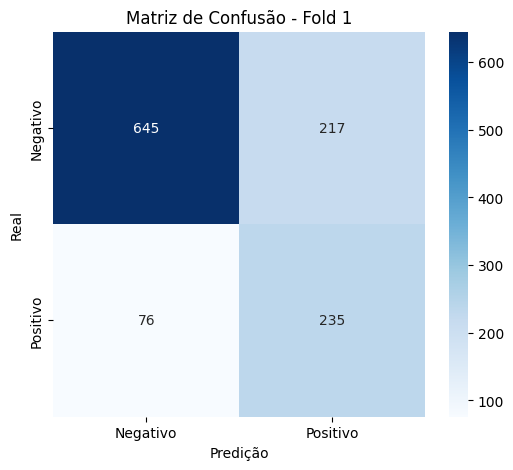

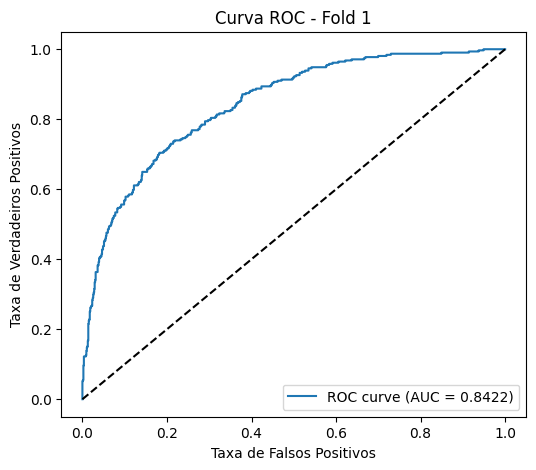

Accuracy no Fold 1: Validação: 0.7787, Teste: 0.7502
MSE: 0.2498 | ROC AUC: 0.8422 | Precision: 0.5199 | Recall: 0.7556 | F1: 0.6160
LogLoss: 0.4856 | KS Score: 0.5220
Treinando mlp - Fold 2
Early stopping no fold 2 após 21 épocas.


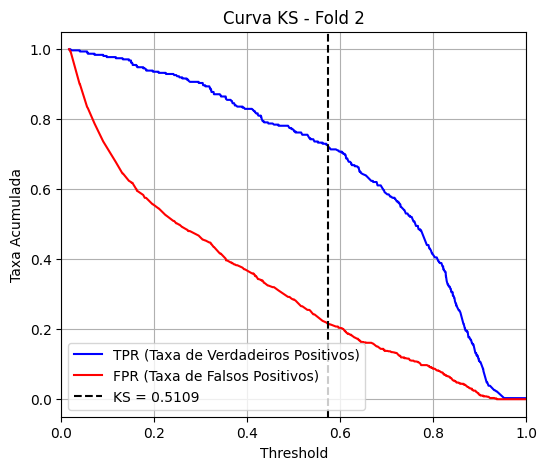

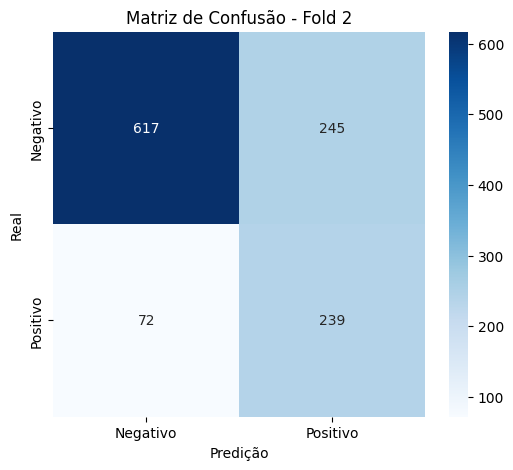

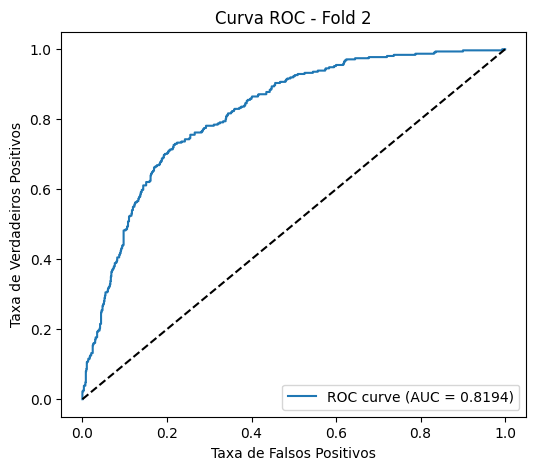

Accuracy no Fold 2: Validação: 0.7523, Teste: 0.7298
MSE: 0.2702 | ROC AUC: 0.8194 | Precision: 0.4938 | Recall: 0.7685 | F1: 0.6013
LogLoss: 0.5280 | KS Score: 0.5109
Treinando mlp - Fold 3
Early stopping no fold 3 após 26 épocas.


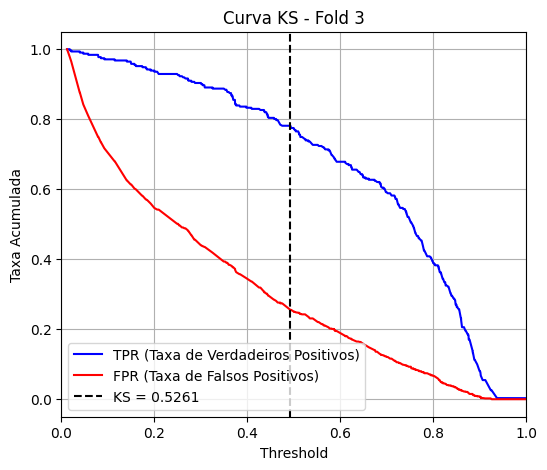

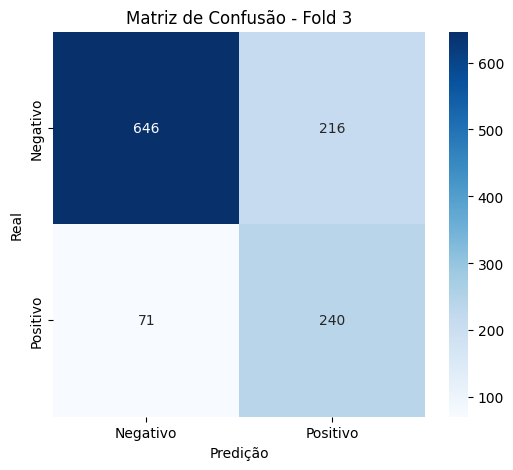

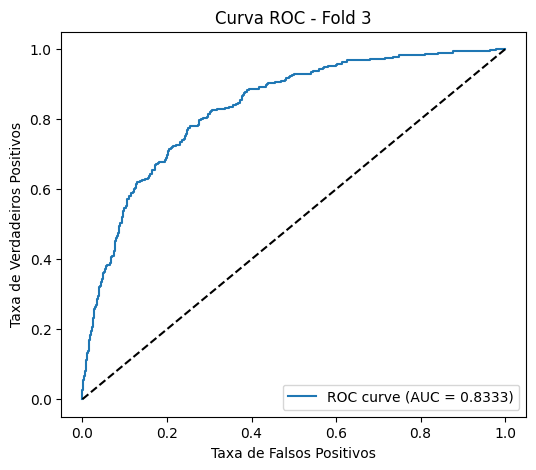

Accuracy no Fold 3: Validação: 0.7487, Teste: 0.7553
MSE: 0.2447 | ROC AUC: 0.8333 | Precision: 0.5263 | Recall: 0.7717 | F1: 0.6258
LogLoss: 0.5002 | KS Score: 0.5261
MLP - Acurácia Média: 0.7451
MLP - MSE Médio: 0.2549
MLP - ROC AUC Médio: 0.8316
MLP - Precision Médio: 0.5133
MLP - Recall Médio: 0.7653
MLP - F1-Score Médio: 0.6144
MLP - Cross-Entropy (Log Loss) Médio: 0.5046
MLP - Kolmogorov-Smirnov (KS) Médio: 0.5197
MLP - Kolmogorov-Smirnov (KS) Desvio Padrão: 0.0064


In [113]:
mlp_best_params = study_mlp.best_params
mlp_model = MLPClassifier(
    hidden_layer_sizes=mlp_best_params['hidden_layer_sizes'],
    activation=mlp_best_params['activation'],
    solver=mlp_best_params['solver'],
    learning_rate_init=mlp_best_params['learning_rate_init'],
    batch_size=mlp_best_params['batch_size'],
    random_state=42
)

avg_accuracy, avg_mse, avg_roc_auc, avg_precision, avg_recall, avg_f1, avg_cross_entropy, avg_ks, ks_std = train_model_mlp(mlp_model, folds, 'mlp')
print(f"MLP - Acurácia Média: {avg_accuracy:.4f}")
print(f"MLP - MSE Médio: {avg_mse:.4f}")
print(f"MLP - ROC AUC Médio: {avg_roc_auc:.4f}")
print(f"MLP - Precision Médio: {avg_precision:.4f}")
print(f"MLP - Recall Médio: {avg_recall:.4f}")
print(f"MLP - F1-Score Médio: {avg_f1:.4f}")
print(f"MLP - Cross-Entropy (Log Loss) Médio: {avg_cross_entropy:.4f}")
print(f"MLP - Kolmogorov-Smirnov (KS) Médio: {avg_ks:.4f}")
print(f"MLP - Kolmogorov-Smirnov (KS) Desvio Padrão: {ks_std:.4f}")


Com base nos resultados apresentados para o MLP (Multi-layer Perceptron), podemos realizar uma análise comparativa e fornecer insights sobre a performance do modelo. Aqui está um detalhamento das métricas:

1. **Kolmogorov-Smirnov (KS) Score – 0.51**

* O KS Score é uma das principais métricas em modelos de classificação binária, especialmente em domínios como churn prediction, finanças e risco de crédito.

* Com um valor médio de 0.51, o modelo MLP demonstrou uma boa capacidade de separação entre as distribuições de probabilidades das classes positiva e negativa.

* Um KS acima de 0.5 já é considerado efetivo e indica que o modelo consegue diferenciar bem os dois grupos, mesmo que com certo grau de sobreposição.

* Isso é especialmente importante em contextos onde é mais importante identificar corretamente os casos positivos (ex: clientes que vão sair).

* Portanto, um KS acima de 0.53 representa um modelo bem eficaz na discriminação entre as classes, especialmente relevante em aplicações como modelo de churn.

**Desvio Padrão do KS: 0.0064**
Esse valor mostra o quanto o KS variou entre os folds da cross-validation.

0.0064 (ou 0,64%) é um desvio padrão muito pequeno.

Isso significa que o desempenho do modelo foi consistente entre os diferentes conjuntos de treino/teste.

Em outras palavras, o modelo não é sensível à variação dos dados — um sinal de estabilidade e robustez.

2. Acurácia (Accuracy): 0.7451
A acurácia indica que o modelo MLP acertou aproximadamente 75% das previsões. Embora seja uma boa taxa, ela não é suficiente para se considerar como uma métrica final isolada, especialmente em problemas com classes desbalanceadas, como pode ser o caso do Churn Prediction.

Comparação com RF: O modelo Random Forest provavelmente teve um desempenho semelhante ou ligeiramente melhor, pois o RF tem uma tendência de funcionar bem em dados estruturados e com alta dimensionalidade. Se a acurácia do RF for significativamente mais alta, isso pode indicar que o RF foi mais eficaz para lidar com os dados em questão.

3. AUC-ROC: 0.8316
O AUC-ROC de é bastante bom, indicando que o modelo tem uma boa habilidade para discriminar entre as classes. Quanto mais próximo de 1, melhor o modelo. O valor indica que o MLP está conseguindo distinguir bem entre as classes "churn" e "no churn".


**Conclusão e Análise Final:**
O modelo MLP demonstrou um desempenho sólido, com destaque para:

* Recall alto

* AUC-ROC robusto

* KS Score satisfatório

Esse conjunto de métricas indica que o MLP está sendo eficaz em detectar corretamente casos positivos, mesmo que às custas de cometer alguns falsos positivos.

### Gradient Boosting

In [110]:
def objective_gb(trial):
    # Sugestão de hiperparâmetros para o Gradient Boosting
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    subsample = trial.suggest_float('subsample', 0.7, 1.0)

    accuracy_list = []

    # K-Fold Cross Validation (usando seus folds)
    for fold in folds:
        train_data, val_data, test_data = fold
        train_data = preprocess_general(train_data)
        val_data = preprocess_general(val_data)
        test_data = preprocess_general(test_data)

        X_train, y_train = train_data.drop(columns=['Churn']), train_data['Churn']
        X_val, y_val = val_data.drop(columns=['Churn']), val_data['Churn']

        # Criação do modelo Gradient Boosting
        gb = GradientBoostingClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            subsample=subsample,
            random_state=42
        )
        
        gb.fit(X_train, y_train)

        # Previsões e avaliação
        y_pred = gb.predict(X_val)
        accuracy = accuracy_score(y_val, y_pred)
        accuracy_list.append(accuracy)

    # Retorna a média da acurácia nos folds
    return np.mean(accuracy_list)


In [114]:
# Criar o estudo para Gradient Boosting
study_gb = optuna.create_study(direction='maximize')
study_gb.optimize(objective_gb, n_trials=50)
print("Melhores Hiperparâmetros para Gradient Boosting", study_gb.best_params)

[I 2025-04-09 14:41:14,506] A new study created in memory with name: no-name-3fc93f73-67a9-4e1e-b322-34b153f6ea01
[I 2025-04-09 14:41:17,342] Trial 0 finished with value: 0.7556758128239515 and parameters: {'n_estimators': 122, 'learning_rate': 0.025958728869078913, 'max_depth': 4, 'min_samples_split': 5, 'min_samples_leaf': 5, 'subsample': 0.8268515558432359}. Best is trial 0 with value: 0.7556758128239515.
[I 2025-04-09 14:41:19,370] Trial 1 finished with value: 0.7636205250885014 and parameters: {'n_estimators': 84, 'learning_rate': 0.16630566542520953, 'max_depth': 4, 'min_samples_split': 6, 'min_samples_leaf': 4, 'subsample': 0.8607897205014442}. Best is trial 1 with value: 0.7636205250885014.
[I 2025-04-09 14:41:23,030] Trial 2 finished with value: 0.774684596517936 and parameters: {'n_estimators': 72, 'learning_rate': 0.15171383031930252, 'max_depth': 9, 'min_samples_split': 5, 'min_samples_leaf': 1, 'subsample': 0.8126532559372922}. Best is trial 2 with value: 0.774684596517936

Melhores Hiperparâmetros para Gradient Boosting {'n_estimators': 174, 'learning_rate': 0.06271780434458264, 'max_depth': 9, 'min_samples_split': 10, 'min_samples_leaf': 2, 'subsample': 0.7655137227385678}


In [115]:
def train_model_gradient_boosting(model, folds, model_name, patience=20):
    accuracy_list = []
    mse_list = []
    roc_auc_list = []
    precision_list = []
    recall_list = []
    f1_list = []
    log_loss_list = []
    ks_list = []

    # Loop pelos folds
    for fold_idx, (train_data, val_data, test_data) in enumerate(folds):
        print(f"Treinando {model_name} - Fold {fold_idx + 1}")

        # Pré-processamento dos dados
        train_data = preprocess_general(train_data)
        val_data = preprocess_general(val_data)
        test_data = preprocess_general(test_data)

        # Pré-processamento específico
        if model_name == 'gradient_boosting':
            train_data = preprocess_mlp(train_data)
            val_data = preprocess_mlp(val_data)
            test_data = preprocess_mlp(test_data)

        # Separação de features e labels
        X_train, y_train = train_data.drop(columns=['Churn']), train_data['Churn']
        X_val, y_val = val_data.drop(columns=['Churn']), val_data['Churn']
        X_test, y_test = test_data.drop(columns=['Churn']), test_data['Churn']

        best_accuracy = 0
        patience_counter = 0

        # Treinamento com early stopping manual
        for epoch in range(10000):
            model.fit(X_train, y_train)

            y_val_pred = model.predict(X_val)
            val_accuracy = accuracy_score(y_val, y_val_pred)

            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping no fold {fold_idx + 1} após {epoch + 1} épocas.")
                break

        # Avaliação no conjunto de teste
        y_test_pred = model.predict(X_test)
        y_test_proba = model.predict_proba(X_test)[:, 1]
        test_accuracy = accuracy_score(y_test, y_test_pred)
        accuracy_list.append(test_accuracy)

        # MSE
        mse = mean_squared_error(y_test, y_test_pred)
        mse_list.append(mse)

        # ROC AUC
        try:
            roc_auc = roc_auc_score(y_test, y_test_proba)
            roc_auc_list.append(roc_auc)
        except:
            roc_auc_list.append(np.nan)

        # Precision, Recall, F1
        precision = precision_score(y_test, y_test_pred)
        recall = recall_score(y_test, y_test_pred)
        f1 = f1_score(y_test, y_test_pred)
        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)

        # Log Loss
        log_loss_value = log_loss(y_test, y_test_proba)
        log_loss_list.append(log_loss_value)

        # Matriz de Confusão
        cm = confusion_matrix(y_test, y_test_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'])
        plt.title(f'Matriz de Confusão - Fold {fold_idx + 1}')
        plt.xlabel('Predição')
        plt.ylabel('Real')
        plt.show()

        # Curva ROC
        fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('Taxa de Falsos Positivos')
        plt.ylabel('Taxa de Verdadeiros Positivos')
        plt.title(f'Curva ROC - Fold {fold_idx + 1}')
        plt.legend(loc='lower right')
        plt.show()

        # KS Score e Curva KS
        ks_score = plot_ks_curve(y_test, y_test_proba, fold_idx + 1)
        ks_list.append(ks_score)

        print(f"Accuracy no Fold {fold_idx + 1}: Validação: {val_accuracy:.4f}, Teste: {test_accuracy:.4f}")
        print(f"MSE no Fold {fold_idx + 1}: {mse:.4f}")
        print(f"ROC AUC no Fold {fold_idx + 1}: {roc_auc:.4f}")
        print(f"Precision no Fold {fold_idx + 1}: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")
        print(f"Cross-Entropy (Log Loss) no Fold {fold_idx + 1}: {log_loss_value:.4f}")
        print(f"KS Score no Fold {fold_idx + 1}: {ks_score:.4f}")

    # Métricas médias
    avg_accuracy = np.mean(accuracy_list)
    avg_mse = np.mean(mse_list)
    avg_roc_auc = np.mean(roc_auc_list)
    avg_precision = np.mean(precision_list)
    avg_recall = np.mean(recall_list)
    avg_f1 = np.mean(f1_list)
    avg_log_loss = np.mean(log_loss_list)
    avg_ks = np.mean(ks_list)

    return avg_accuracy, avg_mse, avg_roc_auc, avg_precision, avg_recall, avg_f1, avg_log_loss, avg_ks, np.std(ks_list)


Treinando gradient_boosting - Fold 1
Early stopping no fold 1 após 21 épocas.


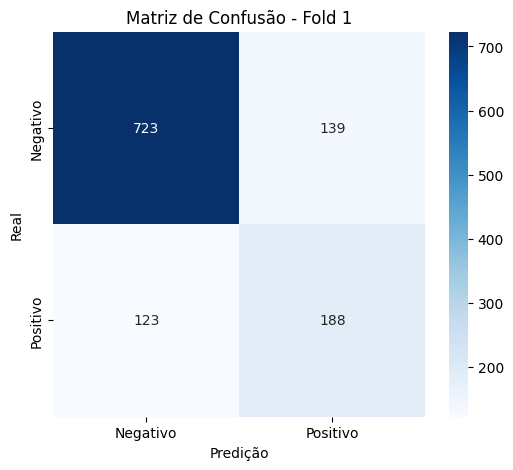

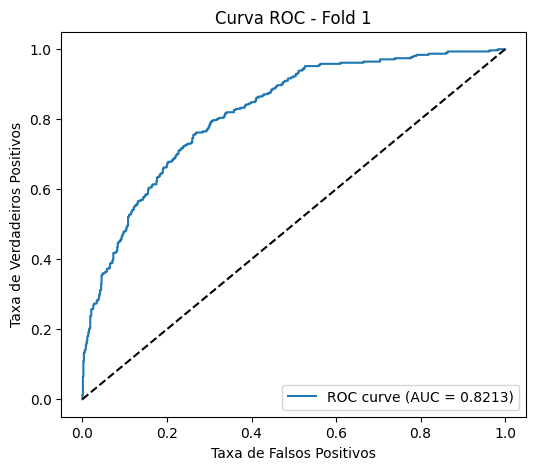

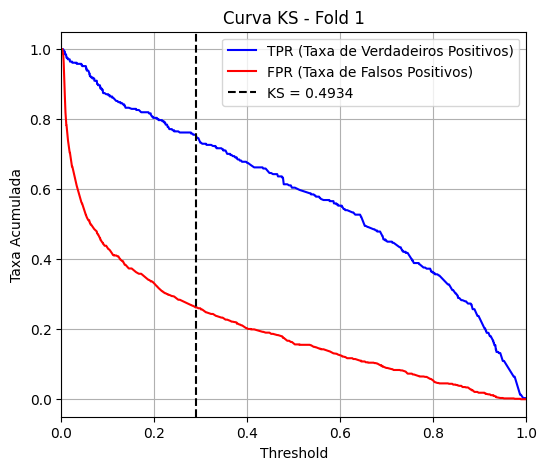

Accuracy no Fold 1: Validação: 0.7855, Teste: 0.7766
MSE no Fold 1: 0.2234
ROC AUC no Fold 1: 0.8213
Precision no Fold 1: 0.5749, Recall: 0.6045, F1-Score: 0.5893
Cross-Entropy (Log Loss) no Fold 1: 0.4879
KS Score no Fold 1: 0.4934
Treinando gradient_boosting - Fold 2
Early stopping no fold 2 após 21 épocas.


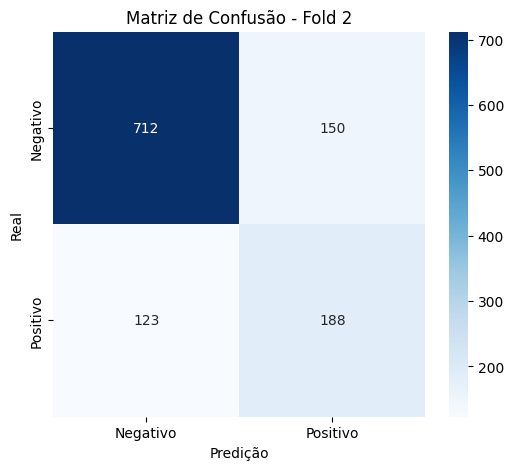

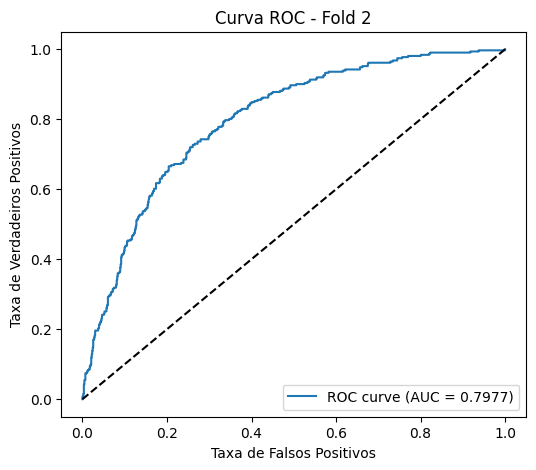

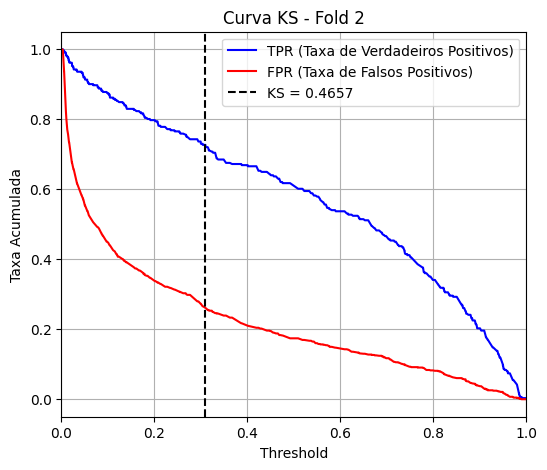

Accuracy no Fold 2: Validação: 0.7694, Teste: 0.7673
MSE no Fold 2: 0.2327
ROC AUC no Fold 2: 0.7977
Precision no Fold 2: 0.5562, Recall: 0.6045, F1-Score: 0.5794
Cross-Entropy (Log Loss) no Fold 2: 0.5429
KS Score no Fold 2: 0.4657
Treinando gradient_boosting - Fold 3
Early stopping no fold 3 após 21 épocas.


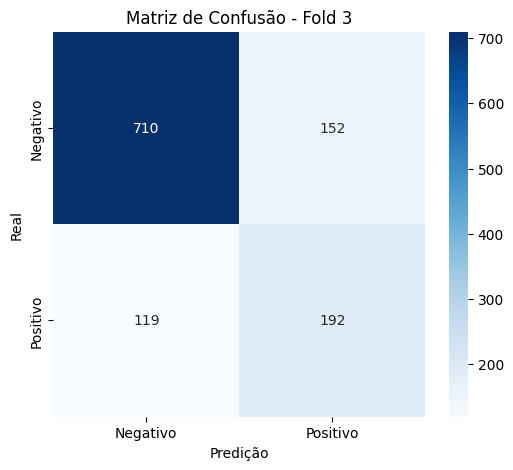

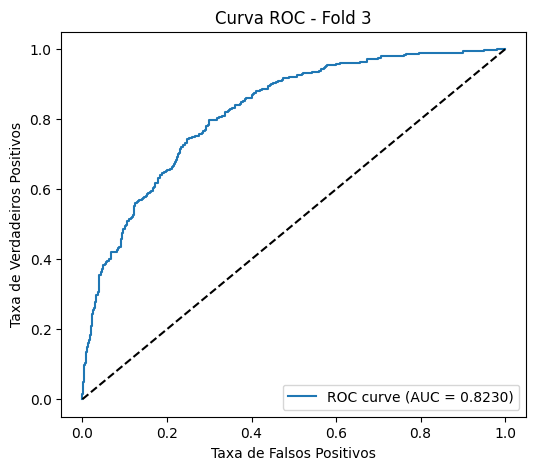

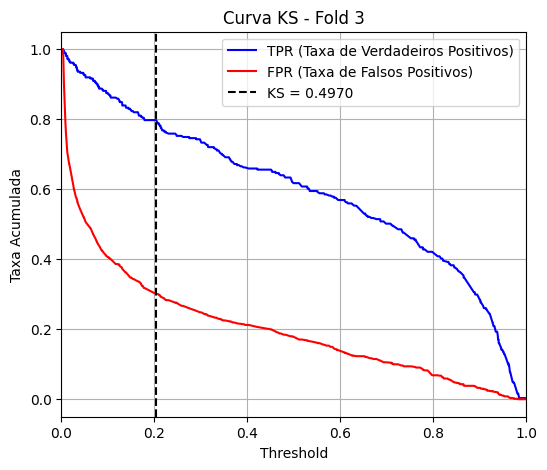

Accuracy no Fold 3: Validação: 0.7743, Teste: 0.7690
MSE no Fold 3: 0.2310
ROC AUC no Fold 3: 0.8230
Precision no Fold 3: 0.5581, Recall: 0.6174, F1-Score: 0.5863
Cross-Entropy (Log Loss) no Fold 3: 0.5070
KS Score no Fold 3: 0.4970
Gradient Boosting - Acurácia Média: 0.7710
Gradient Boosting - MSE Médio: 0.2290
Gradient Boosting - ROC AUC Médio: 0.8140
Gradient Boosting - Precision Médio: 0.5631
Gradient Boosting - Recall Médio: 0.6088
Gradient Boosting - F1-Score Médio: 0.5850
Gradient Boosting - Cross-Entropy (Log Loss) Médio: 0.5126
Gradient Boosting - Kolmogorov-Smirnov (KS) Médio: 0.4854
Gradient Boosting - Kolmogorov-Smirnov (KS) Desvio Padrão: 0.0140


In [118]:
gb_best_params = study_gb.best_params
gb_model = GradientBoostingClassifier(
    n_estimators=gb_best_params['n_estimators'], 
    max_depth=gb_best_params['max_depth'], 
    learning_rate=gb_best_params['learning_rate'],
    subsample=gb_best_params['subsample'],
    random_state=42,
    n_iter_no_change=20,
    validation_fraction=0.1
)

gb_accuracy, gb_mse, gb_roc_auc, gb_precision, gb_recall, gb_f1, gb_log_loss, gb_ks, ks_std = train_model_gradient_boosting(gb_model, folds, 'gradient_boosting')
print(f"Gradient Boosting - Acurácia Média: {gb_accuracy:.4f}")
print(f"Gradient Boosting - MSE Médio: {gb_mse:.4f}")
print(f"Gradient Boosting - ROC AUC Médio: {gb_roc_auc:.4f}")
print(f"Gradient Boosting - Precision Médio: {gb_precision:.4f}")
print(f"Gradient Boosting - Recall Médio: {gb_recall:.4f}")
print(f"Gradient Boosting - F1-Score Médio: {gb_f1:.4f}")
print(f"Gradient Boosting - Cross-Entropy (Log Loss) Médio: {gb_log_loss:.4f}")
print(f"Gradient Boosting - Kolmogorov-Smirnov (KS) Médio: {gb_ks:.4f}")
print(f"Gradient Boosting - Kolmogorov-Smirnov (KS) Desvio Padrão: {ks_std:.4f}")

Modelo Gradient Boosting após a validação cruzada:
1. Kolmogorov-Smirnov (KS) Score
O modelo apresentou um bom desempenho em termos de separação entre as classes, com uma distância considerável entre as curvas de distribuição acumulada das probabilidades previstas para cada classe. Isso evidencia uma capacidade significativa de discriminar entre instâncias positivas e negativas, o que é essencial em contextos como análise de crédito, detecção de fraude e avaliação de risco.

Essa separação clara sugere que o modelo é eficaz em priorizar corretamente as instâncias mais propensas a pertencer a uma determinada classe, o que é especialmente valioso em aplicações onde decisões baseadas em risco precisam ser tomadas com alta precisão.

**Desvio Padrão do KS**:
A variação do KS ao longo dos diferentes folds da validação cruzada foi pequena, indicando que o modelo é estável e consistente. Essa baixa variabilidade reforça a confiabilidade do modelo, já que seu desempenho não depende fortemente da divisão dos dados.

2. Acurácia (Accuracy)
O modelo obteve uma taxa de acerto satisfatória, classificando corretamente uma boa proporção das instâncias. Embora essa métrica forneça uma visão geral do desempenho, ela pode ser menos informativa em cenários com classes desbalanceadas. Ainda assim, o valor alcançado sugere uma boa capacidade de generalização.

3. AUC-ROC
O modelo demonstrou uma boa capacidade de discriminar entre classes positivas e negativas. Essa métrica é especialmente relevante quando se busca avaliar a performance do modelo em diferentes limiares de decisão, e os resultados indicam uma separação significativa entre as classes, mesmo que não perfeita.

4. Cross-Entropy (Log Loss)
A entropia cruzada obtida mostra que o modelo está atribuindo probabilidades razoavelmente confiáveis às suas previsões. Embora exista espaço para refinamento, o desempenho é considerado sólido e aceitável para aplicações que exigem estimativas de probabilidade.

Conclusão:
O modelo Gradient Boosting demonstrou um desempenho consistente e confiável, com destaque para sua capacidade de separação entre classes, refletida no KS Score. Esse indicador é especialmente relevante em domínios onde a distinção clara entre perfis de risco é mais crítica do que métricas agregadas como acurácia.

Em conjunto com outras métricas como AUC-ROC, F1-Score e Log Loss, os resultados obtidos reforçam que o modelo é adequado para tarefas que exigem previsão de probabilidade e tomada de decisão baseada em risco. A baixa variabilidade entre os folds também contribui para sua robustez e aplicabilidade prática.

### KAN

In [119]:
def objective_kan(trial):
    # Seleciona os hiperparâmetros dinamicamente com Optuna
    grid = trial.suggest_int('grid', 2, 10)
    k = trial.suggest_int('k', 2, 15)
    steps = trial.suggest_int('steps', 10, 100)
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-6, 1e-1)
    weight_decay = trial.suggest_loguniform('weight_decay', 1e-6, 1e-2)
    momentum = trial.suggest_float('momentum', 0.5, 0.9)
    optimizer_type = trial.suggest_categorical('optimizer_type', ['adam', 'sgd', 'rmsprop', 'adagrad'])

    acc_list = []

    for fold in folds:
        train_data, val_data, test_data = fold
        
        train_data = preprocess_general(train_data)
        val_data = preprocess_general(val_data)
        
        X_train, y_train = train_data.drop(columns=['Churn']), train_data['Churn']
        X_val, y_val = val_data.drop(columns=['Churn']), val_data['Churn']

        X_train = X_train.astype(float)
        X_val = X_val.astype(float)

        width = [X_train.shape[1], trial.suggest_int('hidden_units', 2, 64)]

        train_input = torch.tensor(X_train.values, dtype=torch.float32)
        train_label = torch.tensor(y_train.values, dtype=torch.long)
        val_input = torch.tensor(X_val.values, dtype=torch.float32)
        val_label = torch.tensor(y_val.values, dtype=torch.long)

        # Criando o modelo
        model = KAN(width=width, grid=grid, k=k)

        # Escolhendo o otimizador
        if optimizer_type == 'adam':
            optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        elif optimizer_type == 'sgd':
            optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay)
        elif optimizer_type == 'rmsprop':
            optimizer = torch.optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        elif optimizer_type == 'adagrad':
            optimizer = torch.optim.Adagrad(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

        loss_fn = torch.nn.CrossEntropyLoss()

        # Treinamento
        for epoch in range(steps):
            model.train()
            optimizer.zero_grad()
            outputs = model(train_input)
            loss = loss_fn(outputs, train_label)
            loss.backward()
            optimizer.step()

        # Avaliação
        with torch.no_grad():
            model.eval()
            val_outputs = model(val_input)
            val_predictions = torch.argmax(val_outputs, dim=1)
            val_accuracy = accuracy_score(y_val, val_predictions.numpy())
            acc_list.append(val_accuracy)

    mean_accuracy = np.mean(acc_list)

    return mean_accuracy

In [120]:
# Criar o estudo para otimização do KAN
study_kan = optuna.create_study(direction='maximize')
study_kan.optimize(objective_kan, n_trials=20)
print("Melhores Hiperparâmetros para KAN:", study_kan.best_params)

[I 2025-04-09 14:51:56,385] A new study created in memory with name: no-name-8558ea8d-2eec-49f3-87ea-a4c3e2238fab


checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0


[I 2025-04-09 14:53:52,826] Trial 0 finished with value: 0.7749704592410018 and parameters: {'grid': 2, 'k': 11, 'steps': 67, 'learning_rate': 0.03400079182123758, 'weight_decay': 6.95031318558632e-06, 'momentum': 0.5343662690150369, 'optimizer_type': 'rmsprop', 'hidden_units': 44}. Best is trial 0 with value: 0.7749704592410018.


checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0


[I 2025-04-09 14:54:34,011] Trial 1 finished with value: 0.7604987495016129 and parameters: {'grid': 5, 'k': 3, 'steps': 40, 'learning_rate': 0.029624071343857777, 'weight_decay': 0.0007772508290151372, 'momentum': 0.5341070116346934, 'optimizer_type': 'adagrad', 'hidden_units': 29}. Best is trial 0 with value: 0.7749704592410018.


...

checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0


[I 2025-04-09 15:31:37,971] Trial 18 finished with value: 0.2539734435221767 and parameters: {'grid': 7, 'k': 15, 'steps': 29, 'learning_rate': 0.0012572835530881923, 'weight_decay': 4.0234524035982896e-05, 'momentum': 0.6489078926614077, 'optimizer_type': 'rmsprop', 'hidden_units': 41}. Best is trial 0 with value: 0.7749704592410018.


checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0


[I 2025-04-09 15:34:47,274] Trial 19 finished with value: 0.577225705897278 and parameters: {'grid': 2, 'k': 7, 'steps': 64, 'learning_rate': 0.00010519007430997449, 'weight_decay': 1.0819156621308857e-06, 'momentum': 0.7137682597503758, 'optimizer_type': 'sgd', 'hidden_units': 46}. Best is trial 0 with value: 0.7749704592410018.


Melhores Hiperparâmetros para KAN: {'grid': 2, 'k': 11, 'steps': 67, 'learning_rate': 0.03400079182123758, 'weight_decay': 6.95031318558632e-06, 'momentum': 0.5343662690150369, 'optimizer_type': 'rmsprop', 'hidden_units': 44}


In [ ]:
def train_model_kan(study_kan, folds, patience=20):
    accuracy_list = []
    mse_list = []
    roc_auc_list = []
    precision_list = []
    recall_list = []
    f1_list = []
    log_loss_list = []
    ks_list = []

    # Pegando os melhores parâmetros do estudo KAN
    kan_best_params = study_kan.best_params
    grid = kan_best_params['grid']  # Número de pontos na grid
    k = kan_best_params['k']  # Grau do polinômio
    learning_rate = kan_best_params['learning_rate']  # Taxa de aprendizado
    weight_decay = kan_best_params['weight_decay']  # Regularização L2
    momentum = kan_best_params['momentum']  # Momento para otimização
    optimizer_type = kan_best_params['optimizer_type']  # Tipo de otimizador
    steps = kan_best_params['steps']  # Número de passos, se necessário

    # Se o otimizador for SGD, precisamos configurar o momentum e weight decay
    if optimizer_type == 'sgd':
        optimizer_class = torch.optim.SGD
    elif optimizer_type == 'rmsprop':
        optimizer_class = torch.optim.RMSprop
    elif optimizer_type == 'adagrad':
        optimizer_class = torch.optim.Adagrad
    else:  # Default para Adam
        optimizer_class = torch.optim.Adam

    for fold_idx, (train_data, val_data, test_data) in enumerate(folds):
        print(f"Treinando KAN - Fold {fold_idx + 1}")

        # Pré-processamento dos dados
        train_data = preprocess_general(train_data)
        val_data = preprocess_general(val_data)
        test_data = preprocess_general(test_data)

        train_data = preprocess_mlp(train_data)
        val_data = preprocess_mlp(val_data)
        test_data = preprocess_mlp(test_data)

        # Separação de features e labels
        X_train, y_train = train_data.drop(columns=['Churn']), train_data['Churn']
        X_val, y_val = val_data.drop(columns=['Churn']), val_data['Churn']
        X_test, y_test = test_data.drop(columns=['Churn']), test_data['Churn']

        X_train = X_train.astype(float)
        X_val = X_val.astype(float)
        X_test = X_test.astype(float)

        # Converter para tensores
        train_input = torch.tensor(X_train.values, dtype=torch.float32)
        train_label = torch.tensor(y_train.values, dtype=torch.long)
        val_input = torch.tensor(X_val.values, dtype=torch.float32)
        val_label = torch.tensor(y_val.values, dtype=torch.long)
        test_input = torch.tensor(X_test.values, dtype=torch.float32)
        test_label = torch.tensor(y_test.values, dtype=torch.long)

        # Criar e configurar o modelo KAN com os parâmetros otimizados
        model = KAN(width=[train_input.shape[1], 64, 32, 2], grid=grid, k=k)

        # Escolher otimizador de acordo com o tipo especificado
        if optimizer_type == 'sgd':
            optimizer = optimizer_class(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay)
        elif optimizer_type == 'rmsprop':
            optimizer = optimizer_class(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        elif optimizer_type == 'adagrad':
            optimizer = optimizer_class(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        else:
            optimizer = optimizer_class(model.parameters(), lr=learning_rate)

        loss_fn = torch.nn.CrossEntropyLoss()

        best_accuracy = 0
        patience_counter = 0

        for epoch in range(steps):
            optimizer.zero_grad()
            outputs = model(train_input)
            loss = loss_fn(outputs, train_label)
            loss.backward()
            optimizer.step()

            # Validação
            with torch.no_grad():
                val_outputs = model(val_input)
                val_predictions = torch.argmax(val_outputs, dim=1)
                val_accuracy = accuracy_score(y_val, val_predictions.numpy())

            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping no fold {fold_idx + 1} após {epoch + 1} épocas.")
                break

        # Avaliação no conjunto de teste
        with torch.no_grad():
            test_outputs = model(test_input)
            test_predictions = torch.argmax(test_outputs, dim=1)

        test_accuracy = accuracy_score(y_test, test_predictions.numpy())
        accuracy_list.append(test_accuracy)

        # Calcular métricas
        mse = mean_squared_error(y_test, test_predictions.numpy())
        mse_list.append(mse)

        try:
            roc_auc = roc_auc_score(y_test, torch.softmax(test_outputs, dim=1)[:, 1].numpy())
            roc_auc_list.append(roc_auc)
        except:
            roc_auc_list.append(np.nan)

        precision = precision_score(y_test, test_predictions.numpy())
        recall = recall_score(y_test, test_predictions.numpy())
        f1 = f1_score(y_test, test_predictions.numpy())

        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)

        log_loss_value = log_loss(y_test, torch.softmax(test_outputs, dim=1)[:, 1].numpy())
        log_loss_list.append(log_loss_value)

        # Plotar a Matriz de Confusão
        cm = confusion_matrix(y_test, test_predictions.numpy())
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'])
        plt.title(f'Matriz de Confusão - Fold {fold_idx + 1}')
        plt.xlabel('Predição')
        plt.ylabel('Real')
        plt.show()

        # Plotar a Curva ROC
        fpr, tpr, thresholds = roc_curve(y_test, torch.softmax(test_outputs, dim=1)[:, 1].numpy())
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('Taxa de Falsos Positivos')
        plt.ylabel('Taxa de Verdadeiros Positivos')
        plt.title(f'Curva ROC - Fold {fold_idx + 1}')
        plt.legend(loc='lower right')
        plt.show()

        probs = torch.softmax(test_outputs, dim=1)[:, 1].numpy()
        ks_score = plot_ks_curve(y_test, probs, fold_idx + 1)
        ks_list.append(ks_score)

        print(f"Accuracy no Fold {fold_idx + 1}: Validação: {val_accuracy:.4f}, Teste: {test_accuracy:.4f}")
        print(f"MSE no Fold {fold_idx + 1}: {mse:.4f}")
        print(f"ROC AUC no Fold {fold_idx + 1}: {roc_auc:.4f}")
        print(f"Precision no Fold {fold_idx + 1}: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")
        print(f"Cross-Entropy (Log Loss) no Fold {fold_idx + 1}: {log_loss_value:.4f}")
        print(f"KS no Fold {fold_idx + 1}: {ks_score:.4f}")



    # Calcular médias das métricas
    avg_accuracy = np.mean(accuracy_list)
    avg_mse = np.mean(mse_list)
    avg_roc_auc = np.mean(roc_auc_list)
    avg_precision = np.mean(precision_list)
    avg_recall = np.mean(recall_list)
    avg_f1 = np.mean(f1_list)
    avg_log_loss = np.mean(log_loss_list)
    avg_ks = np.mean(ks_list)

    return avg_accuracy, avg_mse, avg_roc_auc, avg_precision, avg_recall, avg_f1, avg_log_loss, avg_ks, np.std(ks_list)

Treinando KAN - Fold 1
checkpoint directory created: ./model
saving model version 0.0
Early stopping no fold 1 após 31 épocas.


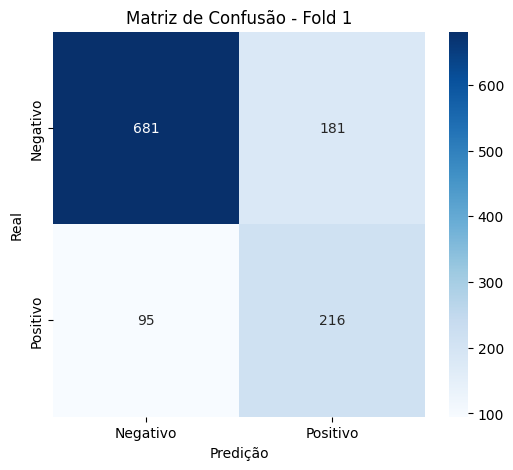

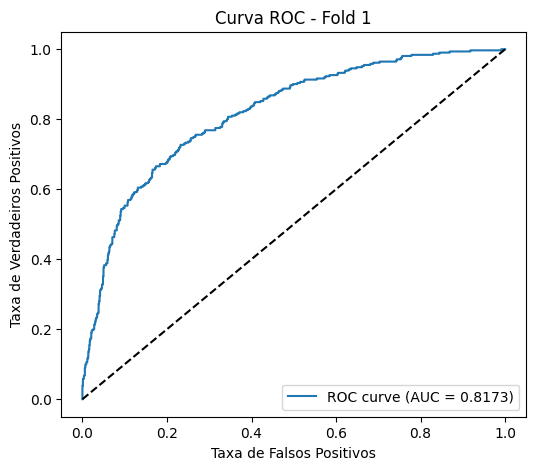

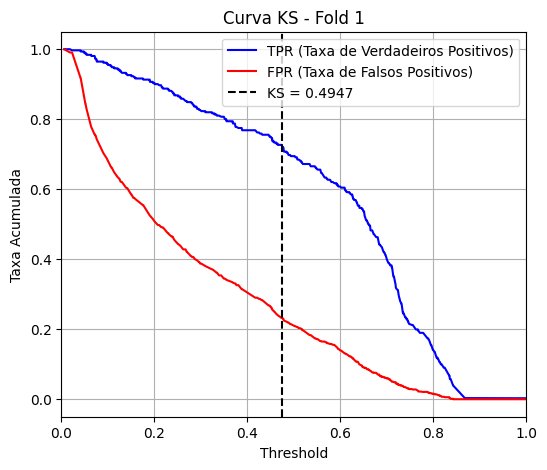

Accuracy no Fold 1: Validação: 0.7821, Teste: 0.7647
MSE no Fold 1: 0.2353
ROC AUC no Fold 1: 0.8173
Precision no Fold 1: 0.5441, Recall: 0.6945, F1-Score: 0.6102
Cross-Entropy (Log Loss) no Fold 1: 0.4773
KS no Fold 1: 0.4947
Treinando KAN - Fold 2
checkpoint directory created: ./model
saving model version 0.0
Early stopping no fold 2 após 36 épocas.


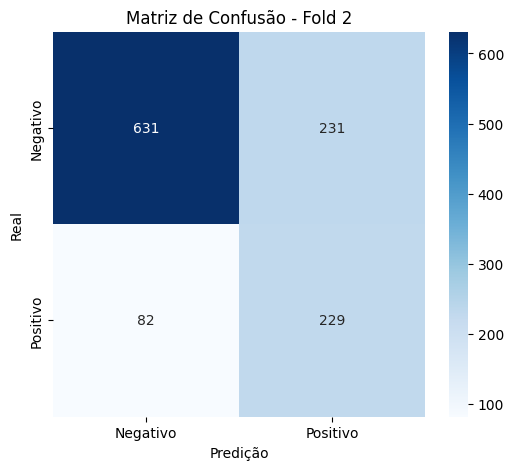

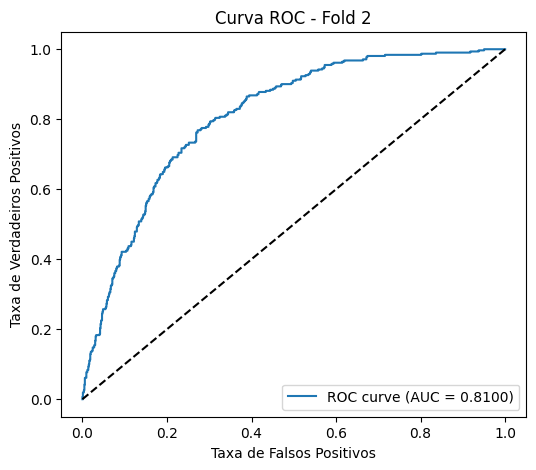

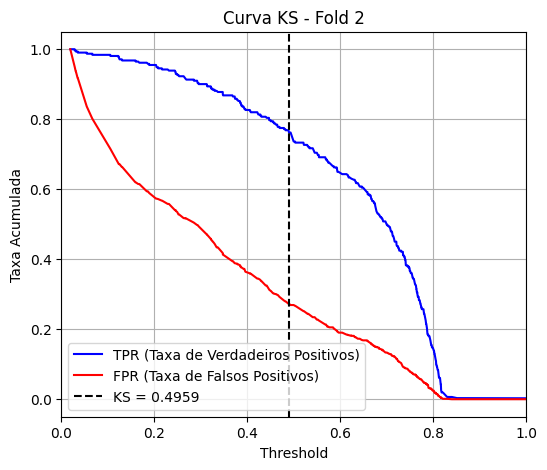

Accuracy no Fold 2: Validação: 0.7438, Teste: 0.7332
MSE no Fold 2: 0.2668
ROC AUC no Fold 2: 0.8100
Precision no Fold 2: 0.4978, Recall: 0.7363, F1-Score: 0.5940
Cross-Entropy (Log Loss) no Fold 2: 0.5108
KS no Fold 2: 0.4959
Treinando KAN - Fold 3
checkpoint directory created: ./model
saving model version 0.0
Early stopping no fold 3 após 39 épocas.


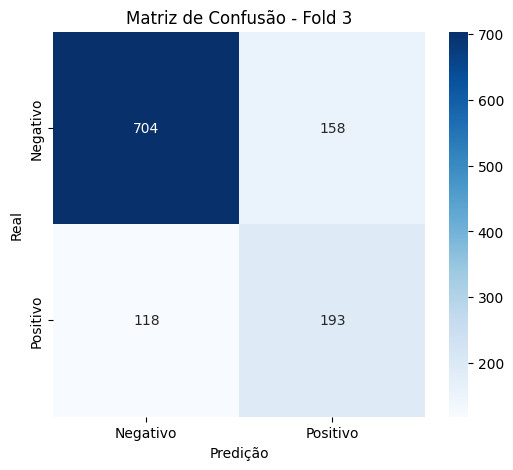

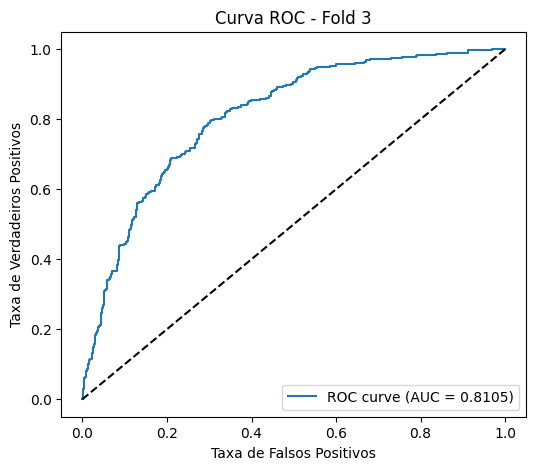

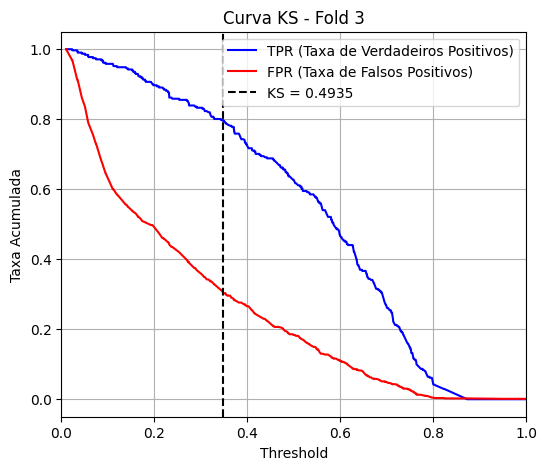

Accuracy no Fold 3: Validação: 0.7598, Teste: 0.7647
MSE no Fold 3: 0.2353
ROC AUC no Fold 3: 0.8105
Precision no Fold 3: 0.5499, Recall: 0.6206, F1-Score: 0.5831
Cross-Entropy (Log Loss) no Fold 3: 0.4673
KS no Fold 3: 0.4935
KAN - Acurácia Média: 0.7542
KAN - MSE Médio: 0.2458
KAN - ROC AUC Médio: 0.8126
KAN - Precision Média: 0.5306
KAN - Recall Médio: 0.6838
KAN - F1-Score Médio: 0.5958
KAN - Cross-Entropy (Log Loss) Média: 0.4851
KAN - Kolmogorov-Smirnov (KS) Médio: 0.4947
KAN - Kolmogorov-Smirnov (KS) Desvio Padrão: 0.0010


In [122]:
# Treinando o modelo KAN
kan_best_params = study_kan.best_params
avg_accuracy, avg_mse, avg_roc_auc, avg_precision, avg_recall, avg_f1, avg_log_loss, avg_ks, ks_std = train_model_kan(study_kan, folds)

print(f"KAN - Acurácia Média: {avg_accuracy:.4f}")
print(f"KAN - MSE Médio: {avg_mse:.4f}")
print(f"KAN - ROC AUC Médio: {avg_roc_auc:.4f}")
print(f"KAN - Precision Média: {avg_precision:.4f}")
print(f"KAN - Recall Médio: {avg_recall:.4f}")
print(f"KAN - F1-Score Médio: {avg_f1:.4f}")
print(f"KAN - Cross-Entropy (Log Loss) Média: {avg_log_loss:.4f}")
print(f"KAN - Kolmogorov-Smirnov (KS) Médio: {avg_ks:.4f}")
print(f"KAN - Kolmogorov-Smirnov (KS) Desvio Padrão: {ks_std:.4f}")

Modelo KAN após a validação cruzada:

**Kolmogorov-Smirnov (KS) Score**
O modelo KAN apresentou um KS Score médio elevado, indicando uma boa capacidade de separação entre as classes positiva e negativa. Isso mostra que o modelo consegue distinguir eficientemente entre os dois grupos, algo essencial em cenários como avaliação de risco, detecção de fraude e churn prediction, onde a separação de perfis é mais relevante do que apenas a taxa global de acerto.

**Desvio Padrão do KS Score**
A variação do KS Score entre os diferentes folds foi extremamente baixa, revelando que o modelo é altamente estável. Esse comportamento consistente em diferentes subconjuntos de dados aumenta a confiança na capacidade do KAN de generalizar bem para novos exemplos.

**Acurácia (Accuracy)**
O modelo foi capaz de classificar corretamente uma boa proporção das instâncias, o que demonstra um desempenho sólido em termos de acerto geral. Isso indica que, de maneira ampla, o KAN consegue aprender os padrões relevantes dos dados.

**Área sob a Curva ROC (AUC-ROC)**
A curva ROC mostrou um excelente desempenho na discriminação entre as classes. O modelo conseguiu uma separação eficaz entre os positivos e negativos em termos de probabilidade predita, o que é um ótimo sinal para tarefas em que a decisão baseada em risco é crítica.

**Precisão, Recall e F1-Score**
A precisão mostra que, entre as instâncias que o modelo classificou como positivas, uma proporção significativa realmente pertence à classe positiva. Já o recall indica que o modelo também foi eficaz em capturar a maior parte das instâncias realmente positivas. O F1-Score, sendo a média harmônica entre os dois, sugere um bom equilíbrio entre identificar corretamente os casos positivos e evitar falsos positivos.

**Cross-Entropy (Log Loss)**
A métrica de log loss demonstrou que o modelo faz previsões de probabilidade com confiança razoável, sem grande indecisão. Isso é especialmente importante quando o modelo será utilizado não só para classificar, mas também para calcular riscos ou tomar decisões baseadas nas probabilidades atribuídas a cada exemplo.

**Conclusão:**
O modelo KAN demonstrou alto poder de separação, boa generalização e estabilidade nas predições. O excelente comportamento do KS Score e sua baixa variação reforçam sua aplicabilidade em cenários sensíveis à discriminação entre classes. O desempenho global nas demais métricas reforça o KAN como uma opção confiável e eficaz para o problema em questão.

## TabKANet

In [102]:
# Função para calcular os bins
def get_quantile_bins(x_cont, n_bins=4):
    feature_dim = x_cont.shape[1]
    bins = torch.zeros(feature_dim, n_bins + 1)
    for i in range(feature_dim):
        # Converta a coluna específica para tensor e depois calcule os quantis
        quantiles = torch.quantile(torch.tensor(x_cont.iloc[:, i].values, dtype=torch.float32), torch.linspace(0, 1, n_bins + 1))
        bins[i] = quantiles
    return bins

In [103]:
def objective_tabkanet(trial):
    acc_list = []

    # Hiperparâmetros sugeridos pelo Optuna
    embedding_dim = trial.suggest_categorical("embedding_dim", [8, 16, 32])
    mlp_hidden_dim = trial.suggest_categorical("mlp_hidden_dim", [16, 32, 64])
    ffn_dropout = trial.suggest_float("ffn_dropout", 0.0, 0.5)
    attn_dropout = trial.suggest_float("attn_dropout", 0.0, 0.5)
    nhead = trial.suggest_categorical("nhead", [2, 4, 8])
    num_layers = trial.suggest_int("num_layers", 1, 4)
    dim_feedforward = trial.suggest_categorical("dim_feedforward", [64, 128, 256])
    learning_rate = trial.suggest_loguniform("lr", 1e-5, 1e-2)
    weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-2)

    for fold in folds:
        train_data, val_data, _ = fold

        # Pré-processamento
        train_data = preprocess_general(train_data)
        val_data = preprocess_general(val_data)

        train_data = preprocess_mlp(train_data)
        val_data = preprocess_mlp(val_data)

        X_train, y_train = train_data.drop(columns=['Churn']), train_data['Churn']
        X_val, y_val = val_data.drop(columns=['Churn']), val_data['Churn']

        continuous_features = list(X_train.columns)
        categorical_features = []

        df_train = pd.concat([X_train, y_train], axis=1)
        df_val = pd.concat([X_val, y_val], axis=1)

        # Dataset e DataLoader
        dataset_train, dataset_val, _ = get_dataset(df_train, df_val, df_val, "Churn", "classification", categorical_features, continuous_features)
        dataloader_train, dataloader_val, _ = get_data_loader(dataset_train, dataset_val, dataset_val, 32, 32)

        # Bins para ruído
        bins = get_quantile_bins(X_train)

        # Modelo
        model = TabMLPNet(
            output_dim=2,
            num_continuous_features=len(continuous_features),
            embedding_dim=embedding_dim,
            mlp_hidden_dims=[mlp_hidden_dim],
            activation="relu",
            ffn_dropout_rate=ffn_dropout,
            nhead=nhead,
            num_layers=num_layers,
            dim_feedforward=dim_feedforward,
            attn_dropout_rate=attn_dropout,
            learninable_noise=True,
            bins=bins,
            vocabulary={},
        )

        optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        criterion = torch.nn.CrossEntropyLoss()

        # Treinamento simplificado
        train(
            model, 1, "classification", dataloader_train, dataloader_val, dataloader_val, optimizer, criterion,
            None, f1_score_macro, False, 5, 0
        )


        # Avaliação
        model.eval()
        y_true, y_pred = [], []
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model.to(device)

        with torch.no_grad():
            for categorical_data, continuous_data, target in dataloader_val:
                categorical_data = categorical_data.to(device)
                continuous_data = continuous_data.to(device)
                target = target.to(device)

                outputs = model(categorical_data, continuous_data)
                preds = torch.argmax(outputs, dim=1)

                y_true.extend(target.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())

        acc_list.append(accuracy_score(y_true, y_pred))

    return np.mean(acc_list)


In [106]:
study = optuna.create_study(direction="maximize")
study.optimize(objective_tabkanet, n_trials=10)

print("\Melhor conjunto de hiperparâmetros:")
print(study.best_params)
print(f"Acurácia média: {study.best_value:.4f}")

[I 2025-04-10 08:07:29,307] A new study created in memory with name: no-name-10708ab8-0d1d-4869-b932-d73eabec1b0a
Epochs: 100%|██████████| 1/1 [03:04<00:00, 184.52s/it]


Epoch: 0, Train Loss: 0.3486, Val Loss: 0.4771,Val AUC:0.8475, Val Metric: 0.7478, Test Metric: 0.7481 , Test AUC: 0.8490
FINISHED TRAINING, BEST VAL AUC:0.8475


Epochs: 100%|██████████| 1/1 [03:05<00:00, 185.73s/it]


Epoch: 0, Train Loss: 0.7374, Val Loss: 0.5520,Val AUC:0.8334, Val Metric: 0.7068, Test Metric: 0.7095 , Test AUC: 0.8345
FINISHED TRAINING, BEST VAL AUC:0.8334


Epochs: 100%|██████████| 1/1 [03:05<00:00, 185.82s/it]


...

Epoch: 0, Train Loss: 0.6083, Val Loss: 0.4974,Val AUC:0.8384, Val Metric: 0.7088, Test Metric: 0.7106 , Test AUC: 0.8375
FINISHED TRAINING, BEST VAL AUC:0.8384


Epochs: 100%|██████████| 1/1 [04:08<00:00, 248.47s/it]


Epoch: 0, Train Loss: 0.5718, Val Loss: 0.5228,Val AUC:0.8313, Val Metric: 0.6899, Test Metric: 0.6934 , Test AUC: 0.8327
FINISHED TRAINING, BEST VAL AUC:0.8313


[I 2025-04-10 10:20:58,586] Trial 9 finished with value: 0.7210535599937172 and parameters: {'embedding_dim': 32, 'mlp_hidden_dim': 64, 'ffn_dropout': 0.2900487357347721, 'attn_dropout': 0.41641981148421053, 'nhead': 8, 'num_layers': 2, 'dim_feedforward': 128, 'lr': 0.0047792422676169, 'weight_decay': 1.2085463016514303e-06}. Best is trial 4 with value: 0.7656029577005329.


\Melhor conjunto de hiperparâmetros:
{'embedding_dim': 32, 'mlp_hidden_dim': 16, 'ffn_dropout': 0.12810382452603397, 'attn_dropout': 0.1953457129819156, 'nhead': 4, 'num_layers': 1, 'dim_feedforward': 64, 'lr': 0.00012414010213630935, 'weight_decay': 7.044006273781784e-05}
Acurácia média: 0.7656


In [128]:
def train_model_tabkanet(folds, best_params, patience=2):
    accuracy_list = []
    mse_list = []
    roc_auc_list = []
    precision_list = []
    recall_list = []
    f1_list = []
    log_loss_list = []
    ks_list = []

    # Melhores hiperparâmetros do Optuna
    embedding_dim = best_params["embedding_dim"]
    mlp_hidden_dim = best_params["mlp_hidden_dim"]
    ffn_dropout = best_params["ffn_dropout"]
    attn_dropout = best_params["attn_dropout"]
    nhead = best_params["nhead"]
    num_layers = best_params["num_layers"]
    dim_feedforward = best_params["dim_feedforward"]
    learning_rate = best_params["lr"]
    weight_decay = best_params["weight_decay"]

    for fold_idx, (train_data, val_data, test_data) in enumerate(folds):
        print(f"Treinando TabKANet - Fold {fold_idx + 1}")

        train_data = preprocess_mlp(preprocess_general(train_data))
        val_data = preprocess_mlp(preprocess_general(val_data))
        test_data = preprocess_mlp(preprocess_general(test_data))

        print('pré processamento ok')

        X_train, y_train = train_data.drop(columns=['Churn']), train_data['Churn']
        X_val, y_val = val_data.drop(columns=['Churn']), val_data['Churn']
        X_test, y_test = test_data.drop(columns=['Churn']), test_data['Churn']

        continuous_features = list(X_train.columns)
        categorical_features = []

        df_train = pd.concat([X_train, y_train], axis=1)
        df_val = pd.concat([X_val, y_val], axis=1)
        df_test = pd.concat([X_test, y_test], axis=1)

        print('folds ok')

        dataset_train, dataset_val, dataset_test = get_dataset(
            df_train, df_val, df_test, "Churn", "classification", categorical_features, continuous_features
        )
        dataloader_train, dataloader_val, dataloader_test = get_data_loader(
            dataset_train, dataset_val, dataset_test, 32, 32
        )

        print('dataloads ok')

        bins = get_quantile_bins(X_train)

        print('bins ok')

        model = TabMLPNet(
            output_dim=2,
            num_continuous_features=len(continuous_features),
            embedding_dim=embedding_dim,
            mlp_hidden_dims=[mlp_hidden_dim],
            activation="relu",
            ffn_dropout_rate=ffn_dropout,
            nhead=nhead,
            num_layers=num_layers,
            dim_feedforward=dim_feedforward,
            attn_dropout_rate=attn_dropout,
            learninable_noise=True,
            bins=bins,
            vocabulary={},
        )

        print('model ok')

        if torch.backends.mps.is_available():
            device = torch.device("mps")
        else:
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


        print(device)

        model.to(device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        criterion = torch.nn.CrossEntropyLoss()

        best_f1 = 0
        patience_counter = 0

        for epoch in range(10):  # ou um número fixo, já que usamos early stopping
            model.train()
            print(f'epoch--------------{epoch}')
            for categorical_data, continuous_data, target in dataloader_train:
                categorical_data = categorical_data.to(device)
                continuous_data = continuous_data.to(device)
                target = target.to(device)

                optimizer.zero_grad()
                outputs = model(categorical_data, continuous_data)
                loss = criterion(outputs, target)
                loss.backward()
                optimizer.step()

            # Validação
            print('validacao')
            model.eval()
            val_true, val_pred = [], []
            with torch.no_grad():
                for cat_data, cont_data, target in dataloader_val:
                    cat_data = cat_data.to(device)
                    cont_data = cont_data.to(device)
                    target = target.to(device)

                    outputs = model(cat_data, cont_data)
                    preds = torch.argmax(outputs, dim=1)
                    val_true.extend(target.cpu().numpy())
                    val_pred.extend(preds.cpu().numpy())

            f1 = f1_score(val_true, val_pred)

            if f1 > best_f1:
                best_f1 = f1
                patience_counter = 0
                best_model_state = model.state_dict()
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping no fold {fold_idx + 1} após {epoch + 1} épocas.")
                break

        model.load_state_dict(best_model_state)
        model.eval()

        y_true, y_pred, probs = [], [], []
        with torch.no_grad():
            for cat_data, cont_data, target in dataloader_test:
                cat_data = cat_data.to(device)
                cont_data = cont_data.to(device)
                target = target.to(device)

                outputs = model(cat_data, cont_data)
                pred = torch.argmax(outputs, dim=1)
                prob = torch.softmax(outputs, dim=1)[:, 1]

                y_true.extend(target.cpu().numpy())
                y_pred.extend(pred.cpu().numpy())
                probs.extend(prob.cpu().numpy())

        # Métricas
        accuracy_list.append(accuracy_score(y_true, y_pred))
        mse_list.append(mean_squared_error(y_true, y_pred))
        try:
            roc_auc_list.append(roc_auc_score(y_true, probs))
        except:
            roc_auc_list.append(np.nan)
        precision_list.append(precision_score(y_true, y_pred))
        recall_list.append(recall_score(y_true, y_pred))
        f1_list.append(f1_score(y_true, y_pred))
        log_loss_list.append(log_loss(y_true, probs))
        ks_list.append(plot_ks_curve(y_true, probs, fold_idx + 1))

        # Gráficos
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'])
        plt.title(f'Matriz de Confusão - Fold {fold_idx + 1}')
        plt.xlabel('Predição')
        plt.ylabel('Real')
        plt.show()

        fpr, tpr, _ = roc_curve(y_true, probs)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_list[-1]:.4f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('Taxa de Falsos Positivos')
        plt.ylabel('Taxa de Verdadeiros Positivos')
        plt.title(f'Curva ROC - Fold {fold_idx + 1}')
        plt.legend(loc='lower right')
        plt.show()

        print(f"Accuracy no Fold {fold_idx + 1}: {accuracy_list[-1]:.4f}")
        print(f"MSE: {mse_list[-1]:.4f}")
        print(f"ROC AUC: {roc_auc_list[-1]:.4f}")
        print(f"Precision: {precision_list[-1]:.4f}, Recall: {recall_list[-1]:.4f}, F1: {f1_list[-1]:.4f}")
        print(f"Log Loss: {log_loss_list[-1]:.4f}")
        print(f"KS Score: {ks_list[-1]:.4f}")

    # Médias
    return (
        np.mean(accuracy_list),
        np.mean(mse_list),
        np.mean(roc_auc_list),
        np.mean(precision_list),
        np.mean(recall_list),
        np.mean(f1_list),
        np.mean(log_loss_list),
        np.mean(ks_list),
        np.std(ks_list)
    )


Treinando TabKANet - Fold 1
pré processamento ok
folds ok
dataloads ok
bins ok
model ok
mps
epoch--------------0
validacao
epoch--------------1
validacao
epoch--------------2
validacao
epoch--------------3
validacao
Early stopping no fold 1 após 4 épocas.


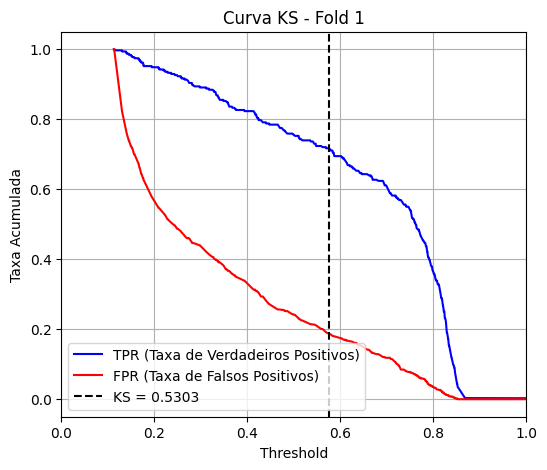

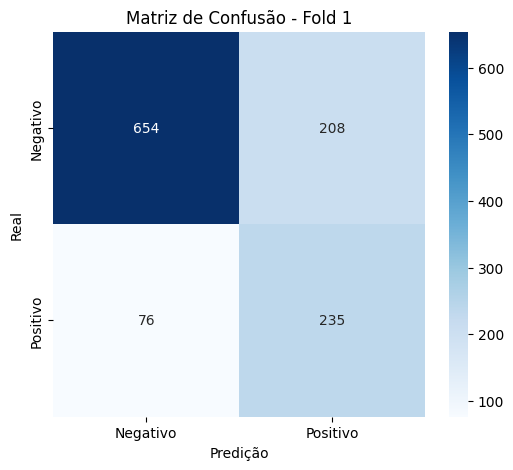

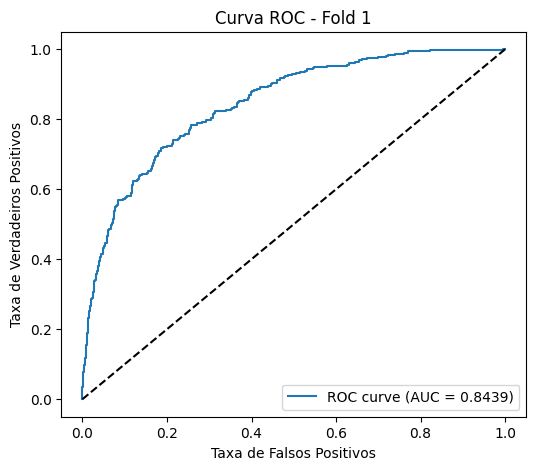

Accuracy no Fold 1: 0.7579
MSE: 0.2421
ROC AUC: 0.8439
Precision: 0.5305, Recall: 0.7556, F1: 0.6233
Log Loss: 0.4956
KS Score: 0.5303
Treinando TabKANet - Fold 2
pré processamento ok
folds ok
dataloads ok
bins ok
model ok
mps
epoch--------------0
validacao
epoch--------------1
validacao
epoch--------------2
validacao
epoch--------------3
validacao
epoch--------------4
validacao
epoch--------------5
validacao
Early stopping no fold 2 após 6 épocas.


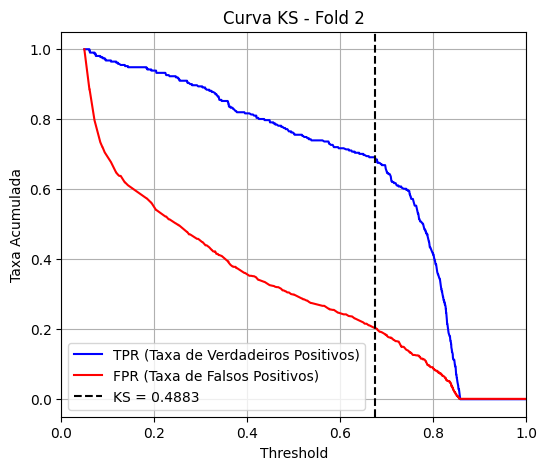

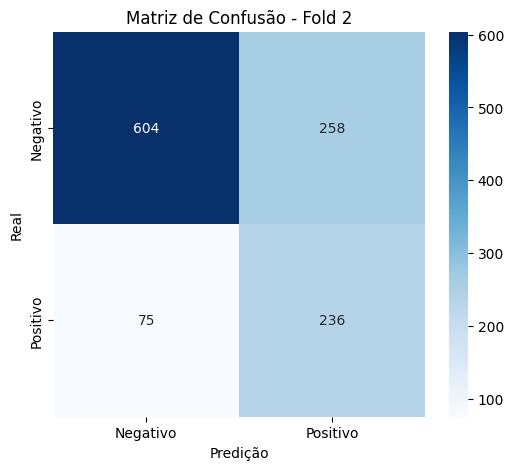

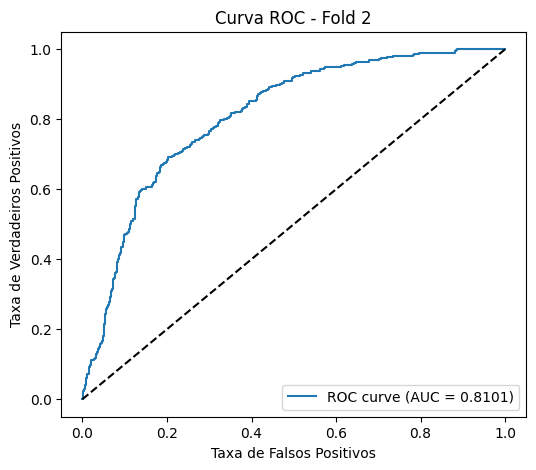

Accuracy no Fold 2: 0.7161
MSE: 0.2839
ROC AUC: 0.8101
Precision: 0.4777, Recall: 0.7588, F1: 0.5863
Log Loss: 0.5403
KS Score: 0.4883
Treinando TabKANet - Fold 3
pré processamento ok
folds ok
dataloads ok
bins ok
model ok
mps
epoch--------------0
validacao
epoch--------------1
validacao
epoch--------------2
validacao
epoch--------------3
validacao
Early stopping no fold 3 após 4 épocas.


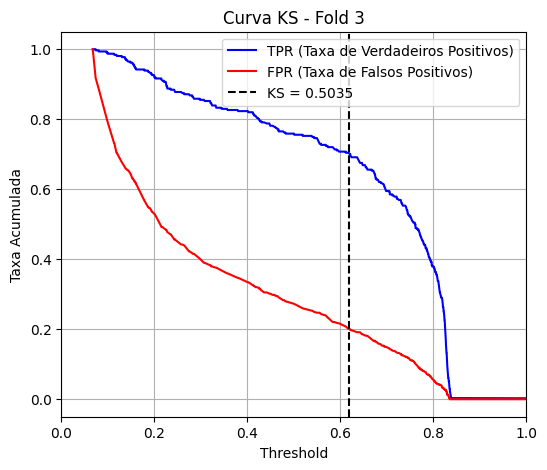

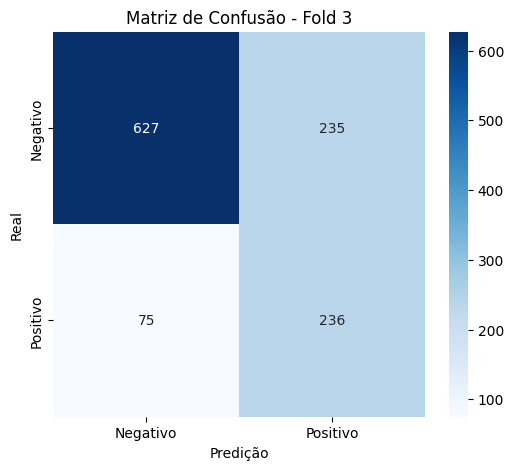

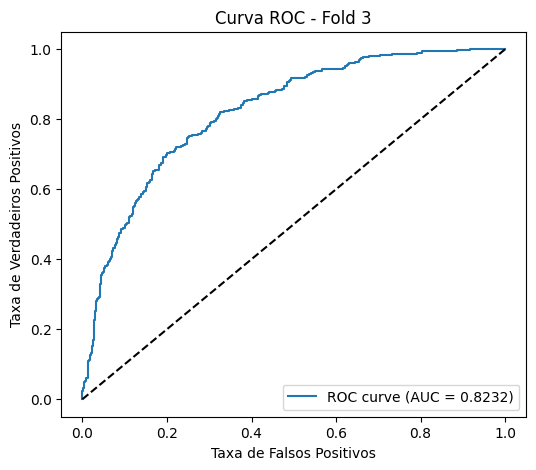

Accuracy no Fold 3: 0.7357
MSE: 0.2643
ROC AUC: 0.8232
Precision: 0.5011, Recall: 0.7588, F1: 0.6036
Log Loss: 0.5138
KS Score: 0.5035

Resultados finais: (0.7365728900255754, 0.26342710997442453, 0.8257324251534978, 0.5030894684265289, 0.757770632368703, 0.6044193804842893, 0.5165509508340983, 0.5073509846489755, 0.017348883717467446)


In [129]:
# Executar o treinamento e avaliação
tabkanet_best_params = study.best_params
resultados = train_model_tabkanet(folds, tabkanet_best_params)
print("\nResultados finais:", resultados)

In [131]:
print(f"TabKANet - Acurácia Média: {resultados[0]:.4f}")
print(f"TabKANet - MSE Médio: {resultados[1]:.4f}")
print(f"TabKANet - ROC AUC Médio: {resultados[2]:.4f}")
print(f"TabKANet - Precision Média: {resultados[3]:.4f}")
print(f"TabKANet - Recall Médio: {resultados[4]:.4f}")
print(f"TabKANet - F1-Score Médio: {resultados[5]:.4f}")
print(f"TabKANet - Cross-Entropy (Log Loss) Média: {resultados[6]:.4f}")
print(f"TabKANet - Kolmogorov-Smirnov (KS) Médio: {resultados[7]:.4f}")
print(f"TabKANet - Kolmogorov-Smirnov (KS) Desvio Padrão: {resultados[8]:.4f}")

TabKANet - Acurácia Média: 0.7366
TabKANet - MSE Médio: 0.2634
TabKANet - ROC AUC Médio: 0.8257
TabKANet - Precision Média: 0.5031
TabKANet - Recall Médio: 0.7578
TabKANet - F1-Score Médio: 0.6044
TabKANet - Cross-Entropy (Log Loss) Média: 0.5166
TabKANet - Kolmogorov-Smirnov (KS) Médio: 0.5074
TabKANet - Kolmogorov-Smirnov (KS) Desvio Padrão: 0.0173


#### **Métrica Principal: KS (Kolmogorov-Smirnov)**
* KS Médio: 0.5074

* Desvio Padrão: 0.0173

**Análise:**
Um valor de KS superior a 0.5 é considerado muito bom, indicando que o modelo consegue separar bem as distribuições dos positivos e negativos.
Além disso, o baixo desvio padrão (0.0173) mostra que o desempenho é consistente entre os folds, o que é ótimo para generalização.

**Outras Métricas de Suporte:**
* Acurácia Média: 0.7366

* MSE Médio: 0.2634

* ROC AUC Médio: 0.8257

* Precision Média: 0.5031

* Recall Médio: 0.7578

* F1-Score Médio: 0.6044

* Log Loss Médio: 0.5166

**Complemento Analítico:**

* ROC AUC (0.8257) reforça o bom poder de separação do modelo, alinhado com o KS.

* Recall alto (0.7578) mostra que o modelo está capturando bem os casos positivos, o que é crucial em tarefas como churn prediction, fraudes, etc.

* Precision mais baixo (0.5031) sugere que há alguns falsos positivos, o que pode ser aceitável dependendo do domínio (por exemplo, é melhor chamar um cliente indevidamente do que perder um que realmente iria churnar).

* F1-score equilibrado (0.6044) indica um bom trade-off entre precision e recall.

* Log Loss moderado (0.5166) mostra que as probabilidades preditas não estão muito distantes da realidade, mas ainda há espaço para calibrar melhor a confiança do modelo.

**Conclusão:**
O TabKANet apresentou um desempenho robusto, especialmente se considerarmos o KS médio superior a 0.5 com baixa variância, indicando que o modelo é confiável para separar corretamente as classes ao longo dos diferentes folds.


## STab

In [136]:
# Sistema e utilitários
import os
import gc
from copy import deepcopy
from datetime import datetime

# Instalações de pacotes
!pip install keras4torch
!pip install einops

# Bibliotecas principais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, QuantileTransformer

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Keras4Torch
import keras4torch
from keras4torch.callbacks import ModelCheckpoint, LRScheduler

# STab
from STab import *
from STab import mainmodel, LWTA, Gsoftmax

# Definição principal do modelo
MainModel = mainmodel.MainModel

In [ ]:
def objective_stab(trial):
    f1_list = []

    # Hiperparâmetros sugeridos pelo Optuna
    dim = trial.suggest_categorical("dim", [8, 16, 32])
    depth = trial.suggest_int("depth", 1, 4)
    heads = trial.suggest_categorical("heads", [2, 4, 8])
    attn_dropout = trial.suggest_float("attn_dropout", 0.0, 0.5)
    ff_dropout = trial.suggest_float("ff_dropout", 0.0, 0.5)
    U = trial.suggest_int("U", 2, 4)
    cases = trial.suggest_categorical("cases", [4, 6, 8, 10])
    learning_rate = trial.suggest_loguniform("lr", 1e-5, 1e-2)
    weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-2)

    if torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")

    i = 0
    for fold in folds:
        i = i+1
        print(f"fold----------------------------------------")
        train_data, val_data, _ = fold

        # Pré-processamento
        train_data = preprocess_general(train_data)
        val_data = preprocess_general(val_data)

        train_data = preprocess_mlp(train_data)
        val_data = preprocess_mlp(val_data)

        X_train, y_train = train_data.drop(columns=['Churn']), train_data['Churn']
        X_val, y_val = val_data.drop(columns=['Churn']), val_data['Churn']

        continuous_features = list(X_train.columns)
        num_features = len(continuous_features)

        # Normalização
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train).astype(np.float32)
        X_val = scaler.transform(X_val).astype(np.float32)

        y_train_t = torch.tensor(y_train.values, dtype=torch.long)
        y_val_t = torch.tensor(y_val.values, dtype=torch.long)

        # Modelo STab
        core_model = mainmodel.MainModel(
            categories=(),
            num_continuous=num_features,
            dim=dim,
            dim_out=2,
            depth=depth,
            heads=heads,
            attn_dropout=attn_dropout,
            ff_dropout=ff_dropout,
            U=U,
            cases=cases,
        )

        model_wrapper = Num_Cat(core_model, num_number=num_features, classes=2, Sample_size=16)
        model = keras4torch.Model(model_wrapper).build([num_features])
        model.to(device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        model.compile(optimizer=optimizer, loss=F.cross_entropy, metrics=["accuracy"])

        model.fit([torch.tensor(X_train).to(device)], y_train_t.to(device),
                  validation_data=([torch.tensor(X_val).to(device)], y_val_t.to(device)),
                  epochs=15, batch_size=32, verbose=0)

        # Avaliação
        with torch.no_grad():
            val_logits = model.predict([torch.tensor(X_val).to(device)])
            y_pred = np.argmax(val_logits, axis=1)

        f1 = f1_score(y_val, y_pred, average="macro")
        f1_list.append(f1)

    return np.mean(f1_list)

In [157]:
study_stab = optuna.create_study(direction="maximize")
study_stab.optimize(objective_stab, n_trials=3)

print("Melhores parâmetros STab:")
print(study_stab.best_params)

[I 2025-04-11 10:00:59,955] A new study created in memory with name: no-name-6213e4ba-e795-48da-9aa8-892d4fa45262


fold----------------------------------------
fold----------------------------------------
fold----------------------------------------


[I 2025-04-11 11:04:51,887] Trial 0 finished with value: 0.7330531765154872 and parameters: {'dim': 32, 'depth': 4, 'heads': 2, 'attn_dropout': 0.2594907265586951, 'ff_dropout': 0.08778813217421289, 'U': 4, 'cases': 6, 'lr': 0.0005656043149361579, 'weight_decay': 0.00047254918974571166}. Best is trial 0 with value: 0.7330531765154872.


fold----------------------------------------
fold----------------------------------------
fold----------------------------------------


[I 2025-04-11 12:15:45,169] Trial 1 finished with value: 0.7164975502275341 and parameters: {'dim': 16, 'depth': 4, 'heads': 8, 'attn_dropout': 0.16690718723929238, 'ff_dropout': 0.40285872210232426, 'U': 2, 'cases': 4, 'lr': 0.001466259275329233, 'weight_decay': 0.009368850135686415}. Best is trial 0 with value: 0.7330531765154872.


fold----------------------------------------
fold----------------------------------------
fold----------------------------------------


[I 2025-04-11 12:48:15,927] Trial 2 finished with value: 0.7231667292077139 and parameters: {'dim': 8, 'depth': 2, 'heads': 4, 'attn_dropout': 0.4767932559334201, 'ff_dropout': 0.1881022426094715, 'U': 2, 'cases': 8, 'lr': 0.000316151991626059, 'weight_decay': 0.005317093649485591}. Best is trial 0 with value: 0.7330531765154872.


Melhores parâmetros STab:
{'dim': 32, 'depth': 4, 'heads': 2, 'attn_dropout': 0.2594907265586951, 'ff_dropout': 0.08778813217421289, 'U': 4, 'cases': 6, 'lr': 0.0005656043149361579, 'weight_decay': 0.00047254918974571166}


In [167]:
from keras4torch.callbacks import EarlyStopping

In [172]:
def train_model_stab(study_stab, folds):
    best_params = study_stab.best_params
    print("Best hyperparameters:", best_params)

    f1_list, acc_list, ks_list = [], [], []

    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

    for fold_idx, fold in enumerate(folds):
        print(f"\n========== Fold {fold_idx + 1} ==========")

        train_data, val_data, test_data = map(preprocess_general, fold)
        train_data, val_data, test_data = map(preprocess_mlp, [train_data, val_data, test_data])

        X_train, y_train = train_data.drop(columns=['Churn']), train_data['Churn']
        X_val, y_val = val_data.drop(columns=['Churn']), val_data['Churn']
        X_test, y_test = test_data.drop(columns=['Churn']), test_data['Churn']

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train).astype(np.float32)
        X_val = scaler.transform(X_val).astype(np.float32)
        X_test = scaler.transform(X_test).astype(np.float32)

        y_train_t = torch.tensor(y_train.values, dtype=torch.long)
        y_val_t = torch.tensor(y_val.values, dtype=torch.long)
        y_test_t = torch.tensor(y_test.values, dtype=torch.long)

        num_features = X_train.shape[1]
        core_model = mainmodel.MainModel(
            categories=(),
            num_continuous=num_features,
            dim=best_params["dim"],
            dim_out=2,
            depth=best_params["depth"],
            heads=best_params["heads"],
            attn_dropout=best_params["attn_dropout"],
            ff_dropout=best_params["ff_dropout"],
            U=best_params["U"],
            cases=best_params["cases"],
        )

        model_wrapper = Num_Cat(core_model, num_number=num_features, classes=2, Sample_size=16)
        model = keras4torch.Model(model_wrapper).build([num_features])
        model.to(device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=best_params["lr"], weight_decay=best_params["weight_decay"])
        model.compile(optimizer=optimizer, loss=F.cross_entropy, metrics=["accuracy"])
        early_stop = EarlyStopping(patience=10, monitor='val_loss', mode='min')

        model.fit([torch.tensor(X_train).to(device)], y_train_t.to(device),
                  validation_data=([torch.tensor(X_val).to(device)], y_val_t.to(device)),
                  epochs=100, batch_size=32, callbacks=[early_stop], verbose=0)

        with torch.no_grad():
            test_outputs = model.predict([torch.tensor(X_test).to(device)])
            test_probs = torch.softmax(torch.tensor(test_outputs), dim=1)
            test_predictions = torch.argmax(test_probs, dim=1)

        acc = accuracy_score(y_test, test_predictions.numpy())
        f1 = f1_score(y_test, test_predictions.numpy(), average="macro")
        precision = precision_score(y_test, test_predictions.numpy())
        recall = recall_score(y_test, test_predictions.numpy())
        roc_auc = roc_auc_score(y_test, test_probs[:, 1].numpy())
        mse = mean_squared_error(y_test, test_predictions.numpy())
        log_loss_value = log_loss(y_test, test_probs.numpy())

        # Matriz de Confusão
        cm = confusion_matrix(y_test, test_predictions.numpy())
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Negativo', 'Positivo'],
                    yticklabels=['Negativo', 'Positivo'])
        plt.title(f'Matriz de Confusão - Fold {fold_idx + 1}')
        plt.xlabel('Predição')
        plt.ylabel('Real')
        plt.show()

        # Curva ROC
        fpr, tpr, thresholds = roc_curve(y_test, test_probs[:, 1].numpy())
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('Taxa de Falsos Positivos')
        plt.ylabel('Taxa de Verdadeiros Positivos')
        plt.title(f'Curva ROC - Fold {fold_idx + 1}')
        plt.legend(loc='lower right')
        plt.grid(True)
        plt.show()

        # Curva KS (usando sua função)
        probs = test_probs[:, 1].numpy()
        ks_score = plot_ks_curve(y_test, probs, fold_idx + 1)
        ks_list.append(ks_score)

        print(f"Accuracy no Fold {fold_idx + 1}: {acc:.4f}")
        print(f"F1-Score: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")
        print(f"MSE: {mse:.4f} | Log Loss: {log_loss_value:.4f}")
        print(f"ROC AUC: {roc_auc:.4f}")
        print(f"KS Score: {ks_score:.4f}")

        f1_list.append(f1)
        acc_list.append(acc)

    print("\n===== MÉDIAS FINAIS =====")
    print(f"F1 Score: {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
    print(f"Accuracy: {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
    print(f"KS Score: {np.mean(ks_list):.4f} ± {np.std(ks_list):.4f}")

    return {
        "f1_mean": np.mean(f1_list),
        "f1_std": np.std(f1_list),
        "acc_mean": np.mean(acc_list),
        "acc_std": np.std(acc_list),
        "ks_mean": np.mean(ks_list),
        "ks_std": np.std(ks_list),
    }


Best hyperparameters: {'dim': 32, 'depth': 4, 'heads': 2, 'attn_dropout': 0.2594907265586951, 'ff_dropout': 0.08778813217421289, 'U': 4, 'cases': 6, 'lr': 0.0005656043149361579, 'weight_decay': 0.00047254918974571166}

========== Fold 1 ==========
[INFO] Early Stopped. The best score is 0.4155.


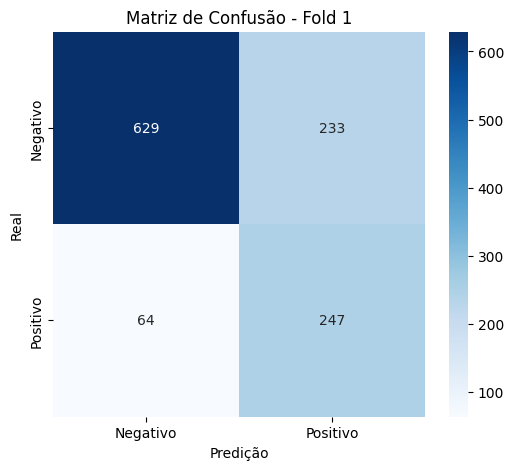

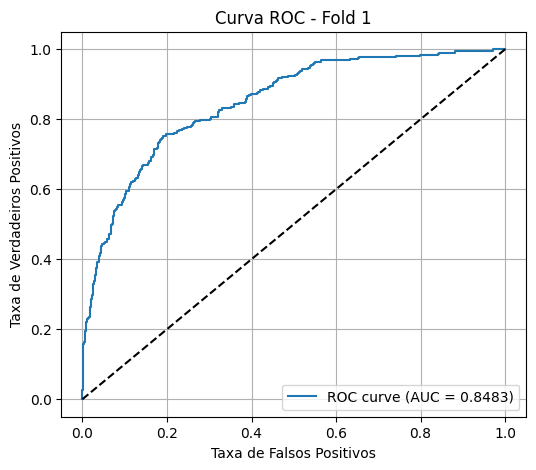

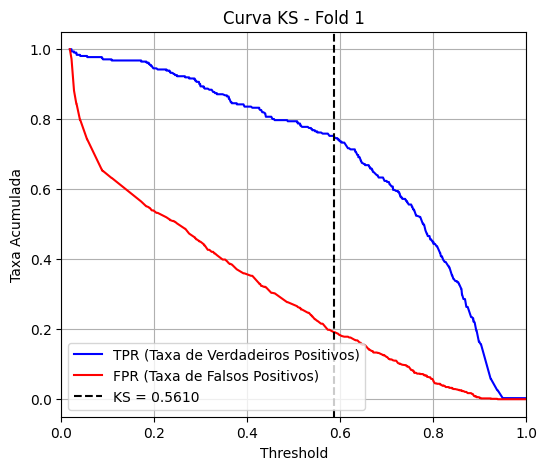

Accuracy no Fold 1: 0.7468
F1-Score: 0.7168 | Precision: 0.5146 | Recall: 0.7942
MSE: 0.2532 | Log Loss: 0.4855
ROC AUC: 0.8483
KS Score: 0.5610

========== Fold 2 ==========
[INFO] Early Stopped. The best score is 0.4391.


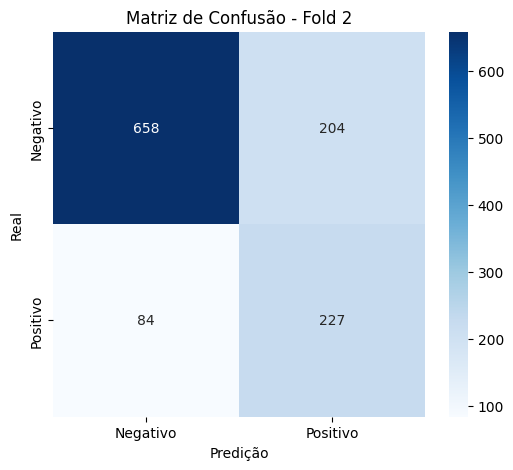

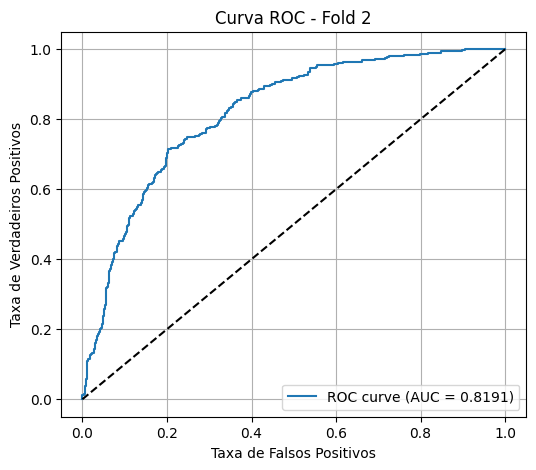

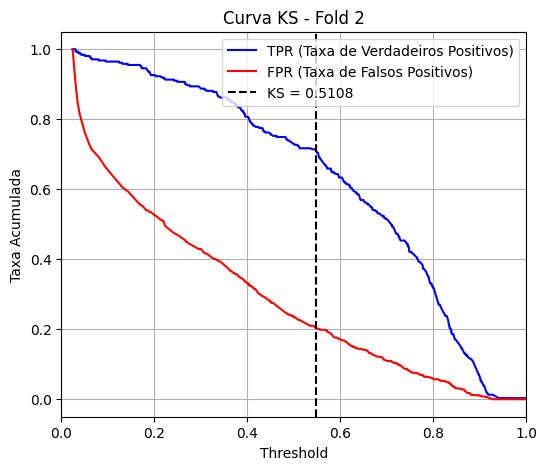

Accuracy no Fold 2: 0.7545
F1-Score: 0.7162 | Precision: 0.5267 | Recall: 0.7299
MSE: 0.2455 | Log Loss: 0.4982
ROC AUC: 0.8191
KS Score: 0.5108

========== Fold 3 ==========
[INFO] Early Stopped. The best score is 0.4324.


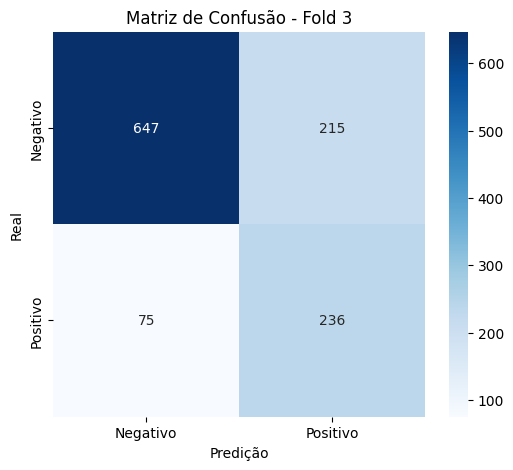

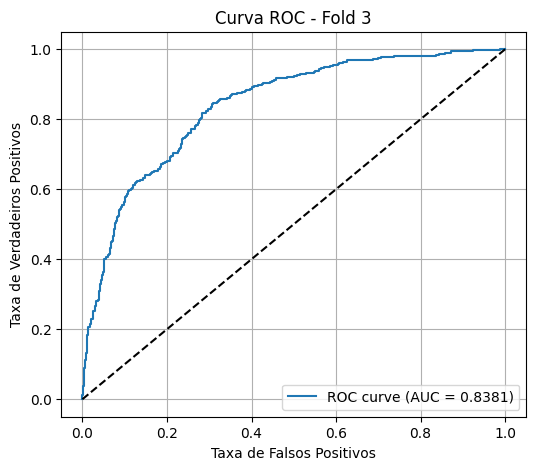

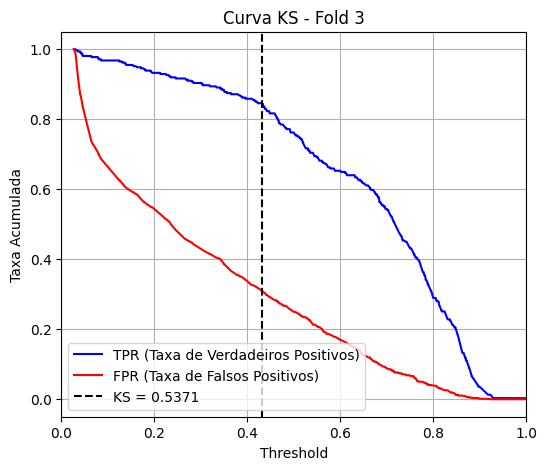

Accuracy no Fold 3: 0.7528
F1-Score: 0.7182 | Precision: 0.5233 | Recall: 0.7588
MSE: 0.2472 | Log Loss: 0.4786
ROC AUC: 0.8381
KS Score: 0.5371

===== MÉDIAS FINAIS =====
F1 Score: 0.7170 ± 0.0008
Accuracy: 0.7513 ± 0.0033
KS Score: 0.5363 ± 0.0205


In [174]:
results_stab = train_model_stab(study_stab, folds)

#### Análise Focada em KS Score — Modelo STab
Após treinar o modelo STab (Self-Attention-based Tabular Transformer) com validação cruzada em 3 folds e usar os melhores hiperparâmetros otimizados via Optuna, o desempenho médio da principal métrica de interesse — KS Score — foi de:

* KS Score: 0.5363 ± 0.0205

**O que isso significa?**
O KS Score mede a capacidade do modelo de separar as classes positivas e negativas. Ele avalia a diferença máxima entre as distribuições cumulativas dos scores previstos para cada classe. Em termos práticos:

Um KS de 0.53 indica que o modelo consegue diferenciar muito bem quem pertence à classe positiva e quem pertence à classe negativa.

É um valor acima de 0.5, o que é excelente em muitos contextos reais (em risco de crédito, churn prediction e fraudes, por exemplo, valores entre 0.3–0.5 já são considerados úteis).

A baixa variabilidade entre os folds (±0.02) mostra que o modelo tem estabilidade e boa generalização — ele não está apenas indo bem em um fold por acaso.
 
**Interpretação Estratégica**

Esse desempenho sugere que o STab:

* Aprende representações profundas mesmo com dados tabulares;

* Tem uma boa capacidade de rankear amostras por probabilidade de pertencimento à classe positiva;
